In [1]:
import os
import pickle

import pandas as pd
import yaml


def read_txt_file(file_path):
    with open(file_path, 'r') as file:
        content = file.read()
    lines = content.split('\n')
    metrics = []
    values = []
    for line in lines[2:]:
        if line.strip():  # Skip empty lines
            metric, value = line.split(':')
            metrics.append(metric.strip())
            values.append(float(value.strip()))
    df = pd.DataFrame({'Metric': metrics, 'Value': values})
    return df

In [2]:
os.path.exists("../../../results/cof_rth_0.98_0.85")

False

In [17]:
results_dir = "../../../results/cof_rth_0.99"

df_summary = []
for model in os.listdir(results_dir):
    model_dir = os.path.join(results_dir, model)
    for dataset in os.listdir(model_dir):
        dataset_dir = os.path.join(model_dir, dataset)
        result_file = os.path.join(dataset_dir, 'aggregated_results.txt')
        try:
            df_metrics = read_txt_file(result_file)
            df_metrics['Model'] = model
            # dataset_name = dataset.replace('rth_1.0', '').replace('True', '').replace('1024', '').replace('sum', '').replace('_', ' ').replace('2', '')
            dataset_name = dataset.replace('rth_1.0', '')
            dataset_name = dataset_name.replace('features', '')
            df_metrics['Dataset'] = dataset_name

            df_summary.append(df_metrics)
        except FileNotFoundError:
            print(f"File not found: {result_file}")
            continue
df_summary = pd.concat(df_summary, ignore_index=True)
df_summary.head()

,Metric,Value,Model,Dataset
0,pairwise_accuracy_score,0.6550,xgboost,_rth_0.99_functional_groups_False
1,baseline_pairwise_accuracy_score,0.5000,xgboost,_rth_0.99_functional_groups_False
2,ndcg_score,0.8193,xgboost,_rth_0.99_functional_groups_False
3,baseline_ndcg_score,0.7627,xgboost,_rth_0.99_functional_groups_False
4,rmse,190.3718,xgboost,_rth_0.99_functional_groups_False


In [18]:
dataset_name_mapping = {
    d: i for i, d in enumerate(sorted(df_summary['Dataset'].unique()))
}
print(dataset_name_mapping)
df_summary['Dataset'] = df_summary['Dataset'].map(dataset_name_mapping)
df_summary.head()

{'_rth_0.99_bcut_': 0, '_rth_0.99_custom_pattern_False': 1, '_rth_0.99_custom_pattern_True': 2, '_rth_0.99_descriptor_': 3, '_rth_0.99_descriptor__custom_pattern_False': 4, '_rth_0.99_descriptor__custom_pattern_True': 5, '_rth_0.99_ecfp_2_1024_False': 6, '_rth_0.99_ecfp_2_1024_False_bcut_': 7, '_rth_0.99_ecfp_2_1024_False_descriptor_': 8, '_rth_0.99_ecfp_2_1024_False_descriptor__custom_pattern_False': 9, '_rth_0.99_ecfp_2_1024_False_estate_sum': 10, '_rth_0.99_ecfp_2_1024_False_physiochemical_False_1024': 11, '_rth_0.99_ecfp_2_1024_False_physiochemical_False_1024_descriptor_': 12, '_rth_0.99_ecfp_2_1024_True': 13, '_rth_0.99_ecfp_2_1024_True_bcut_': 14, '_rth_0.99_ecfp_2_1024_True_descriptor_': 15, '_rth_0.99_ecfp_2_1024_True_descriptor__custom_pattern_True': 16, '_rth_0.99_ecfp_2_1024_True_estate_sum': 17, '_rth_0.99_ecfp_2_1024_True_physiochemical_True_1024': 18, '_rth_0.99_ecfp_2_1024_True_physiochemical_True_1024_descriptor_': 19, '_rth_0.99_estate_sum': 20, '_rth_0.99_functional_g

,Metric,Value,Model,Dataset
0,pairwise_accuracy_score,0.6550,xgboost,21
1,baseline_pairwise_accuracy_score,0.5000,xgboost,21
2,ndcg_score,0.8193,xgboost,21
3,baseline_ndcg_score,0.7627,xgboost,21
4,rmse,190.3718,xgboost,21


In [19]:
def visualize_metric(df, metric_name):
    import seaborn as sns
    import matplotlib.pyplot as plt

    df_metric = df[df['Metric'] == metric_name]
    df_metric_baseline = df[df['Metric'] == f'baseline_{metric_name}']

    df_metric = pd.pivot(df_metric, index='Dataset', columns='Model', values='Value')
    df_metric_baseline = pd.pivot(df_metric_baseline, index='Dataset', columns='Model', values='Value')
    df_metric_baseline = df_metric_baseline.iloc[[0], :]


    #display(df_metric_baseline)
    #display(df_metric)

    fig = plt.figure(figsize=(32, 30))

    if metric_name in ['rmse', 'mae', 'smape', 'mape']:
        cmap = 'magma_r'
        df_metric_small = df_metric[df_metric < df_metric_baseline.values[0][0] * 1.5]
        vmax = df_metric_small.max().max()
        vmin = df_metric_small.min().min()
    else:
        cmap = 'magma'
        df_metric_small = df_metric[df_metric <= 1]
        vmax = df_metric_small.max().max()
        vmin = df_metric_small.min().min()

    # 2. Create a GridSpec with height ratios
    gs = fig.add_gridspec(2, 1, height_ratios=[1, len(df_metric.index)])

    # 3. Add subplots using the GridSpec object
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])

    sns.heatmap(data=df_metric_baseline, annot=True, ax=ax0, cmap=cmap, vmax=vmax, vmin=vmin, fmt=".2f", annot_kws={"size": 20})
    ax0.set_title(f'Baseline {metric_name} Scores')
    ax0.tick_params(axis='x', labelsize=20)
    ax0.tick_params(axis='y', labelsize=20)
    sns.heatmap(data=df_metric.sort_index(), annot=True, ax=ax1, cmap=cmap, vmax=vmax, vmin=vmin, fmt=".2f", annot_kws={"size": 20})
    ax1.set_title(f'{metric_name} Scores by Model')
    ax1.tick_params(axis='x', labelsize=20)
    ax1.tick_params(axis='y', labelsize=20)
    plt.tight_layout()
    plt.show()

In [20]:
dataset_name_mapping

{'_rth_0.99_bcut_': 0,
 '_rth_0.99_custom_pattern_False': 1,
 '_rth_0.99_custom_pattern_True': 2,
 '_rth_0.99_descriptor_': 3,
 '_rth_0.99_descriptor__custom_pattern_False': 4,
 '_rth_0.99_descriptor__custom_pattern_True': 5,
 '_rth_0.99_ecfp_2_1024_False': 6,
 '_rth_0.99_ecfp_2_1024_False_bcut_': 7,
 '_rth_0.99_ecfp_2_1024_False_descriptor_': 8,
 '_rth_0.99_ecfp_2_1024_False_descriptor__custom_pattern_False': 9,
 '_rth_0.99_ecfp_2_1024_False_estate_sum': 10,
 '_rth_0.99_ecfp_2_1024_False_physiochemical_False_1024': 11,
 '_rth_0.99_ecfp_2_1024_False_physiochemical_False_1024_descriptor_': 12,
 '_rth_0.99_ecfp_2_1024_True': 13,
 '_rth_0.99_ecfp_2_1024_True_bcut_': 14,
 '_rth_0.99_ecfp_2_1024_True_descriptor_': 15,
 '_rth_0.99_ecfp_2_1024_True_descriptor__custom_pattern_True': 16,
 '_rth_0.99_ecfp_2_1024_True_estate_sum': 17,
 '_rth_0.99_ecfp_2_1024_True_physiochemical_True_1024': 18,
 '_rth_0.99_ecfp_2_1024_True_physiochemical_True_1024_descriptor_': 19,
 '_rth_0.99_estate_sum': 20,
 '_

pairwise_accuracy_score


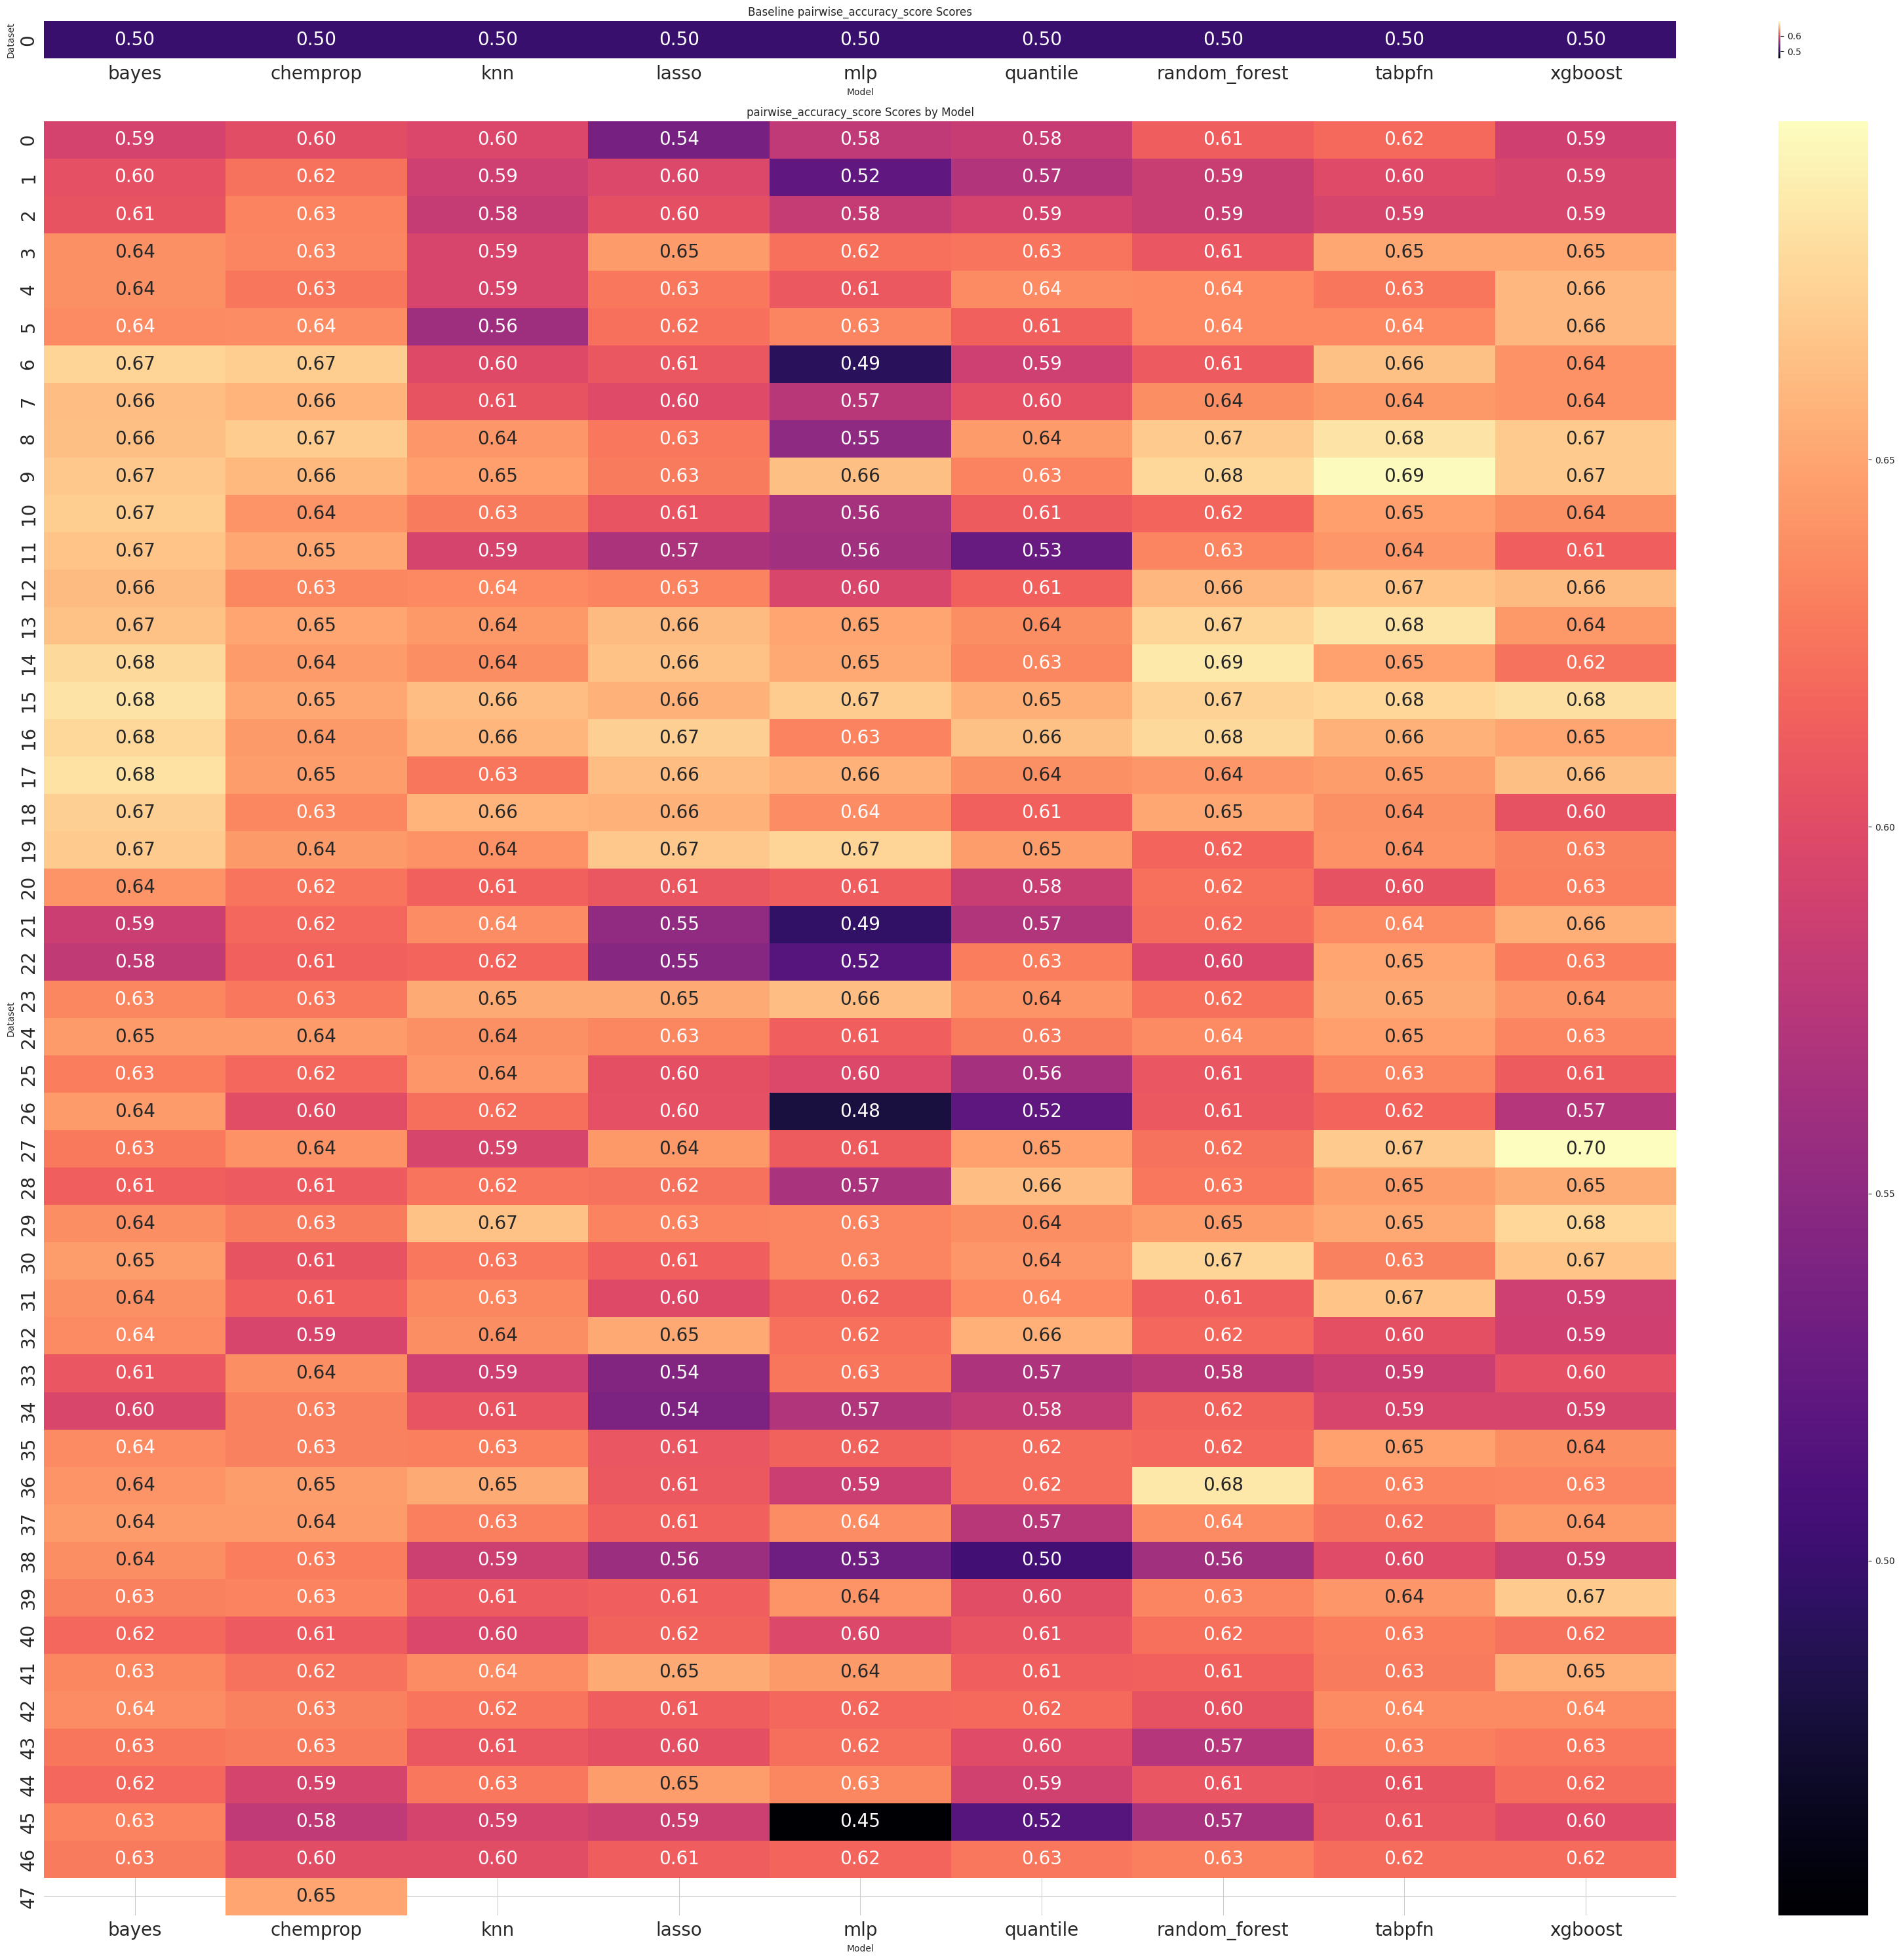

ndcg_score


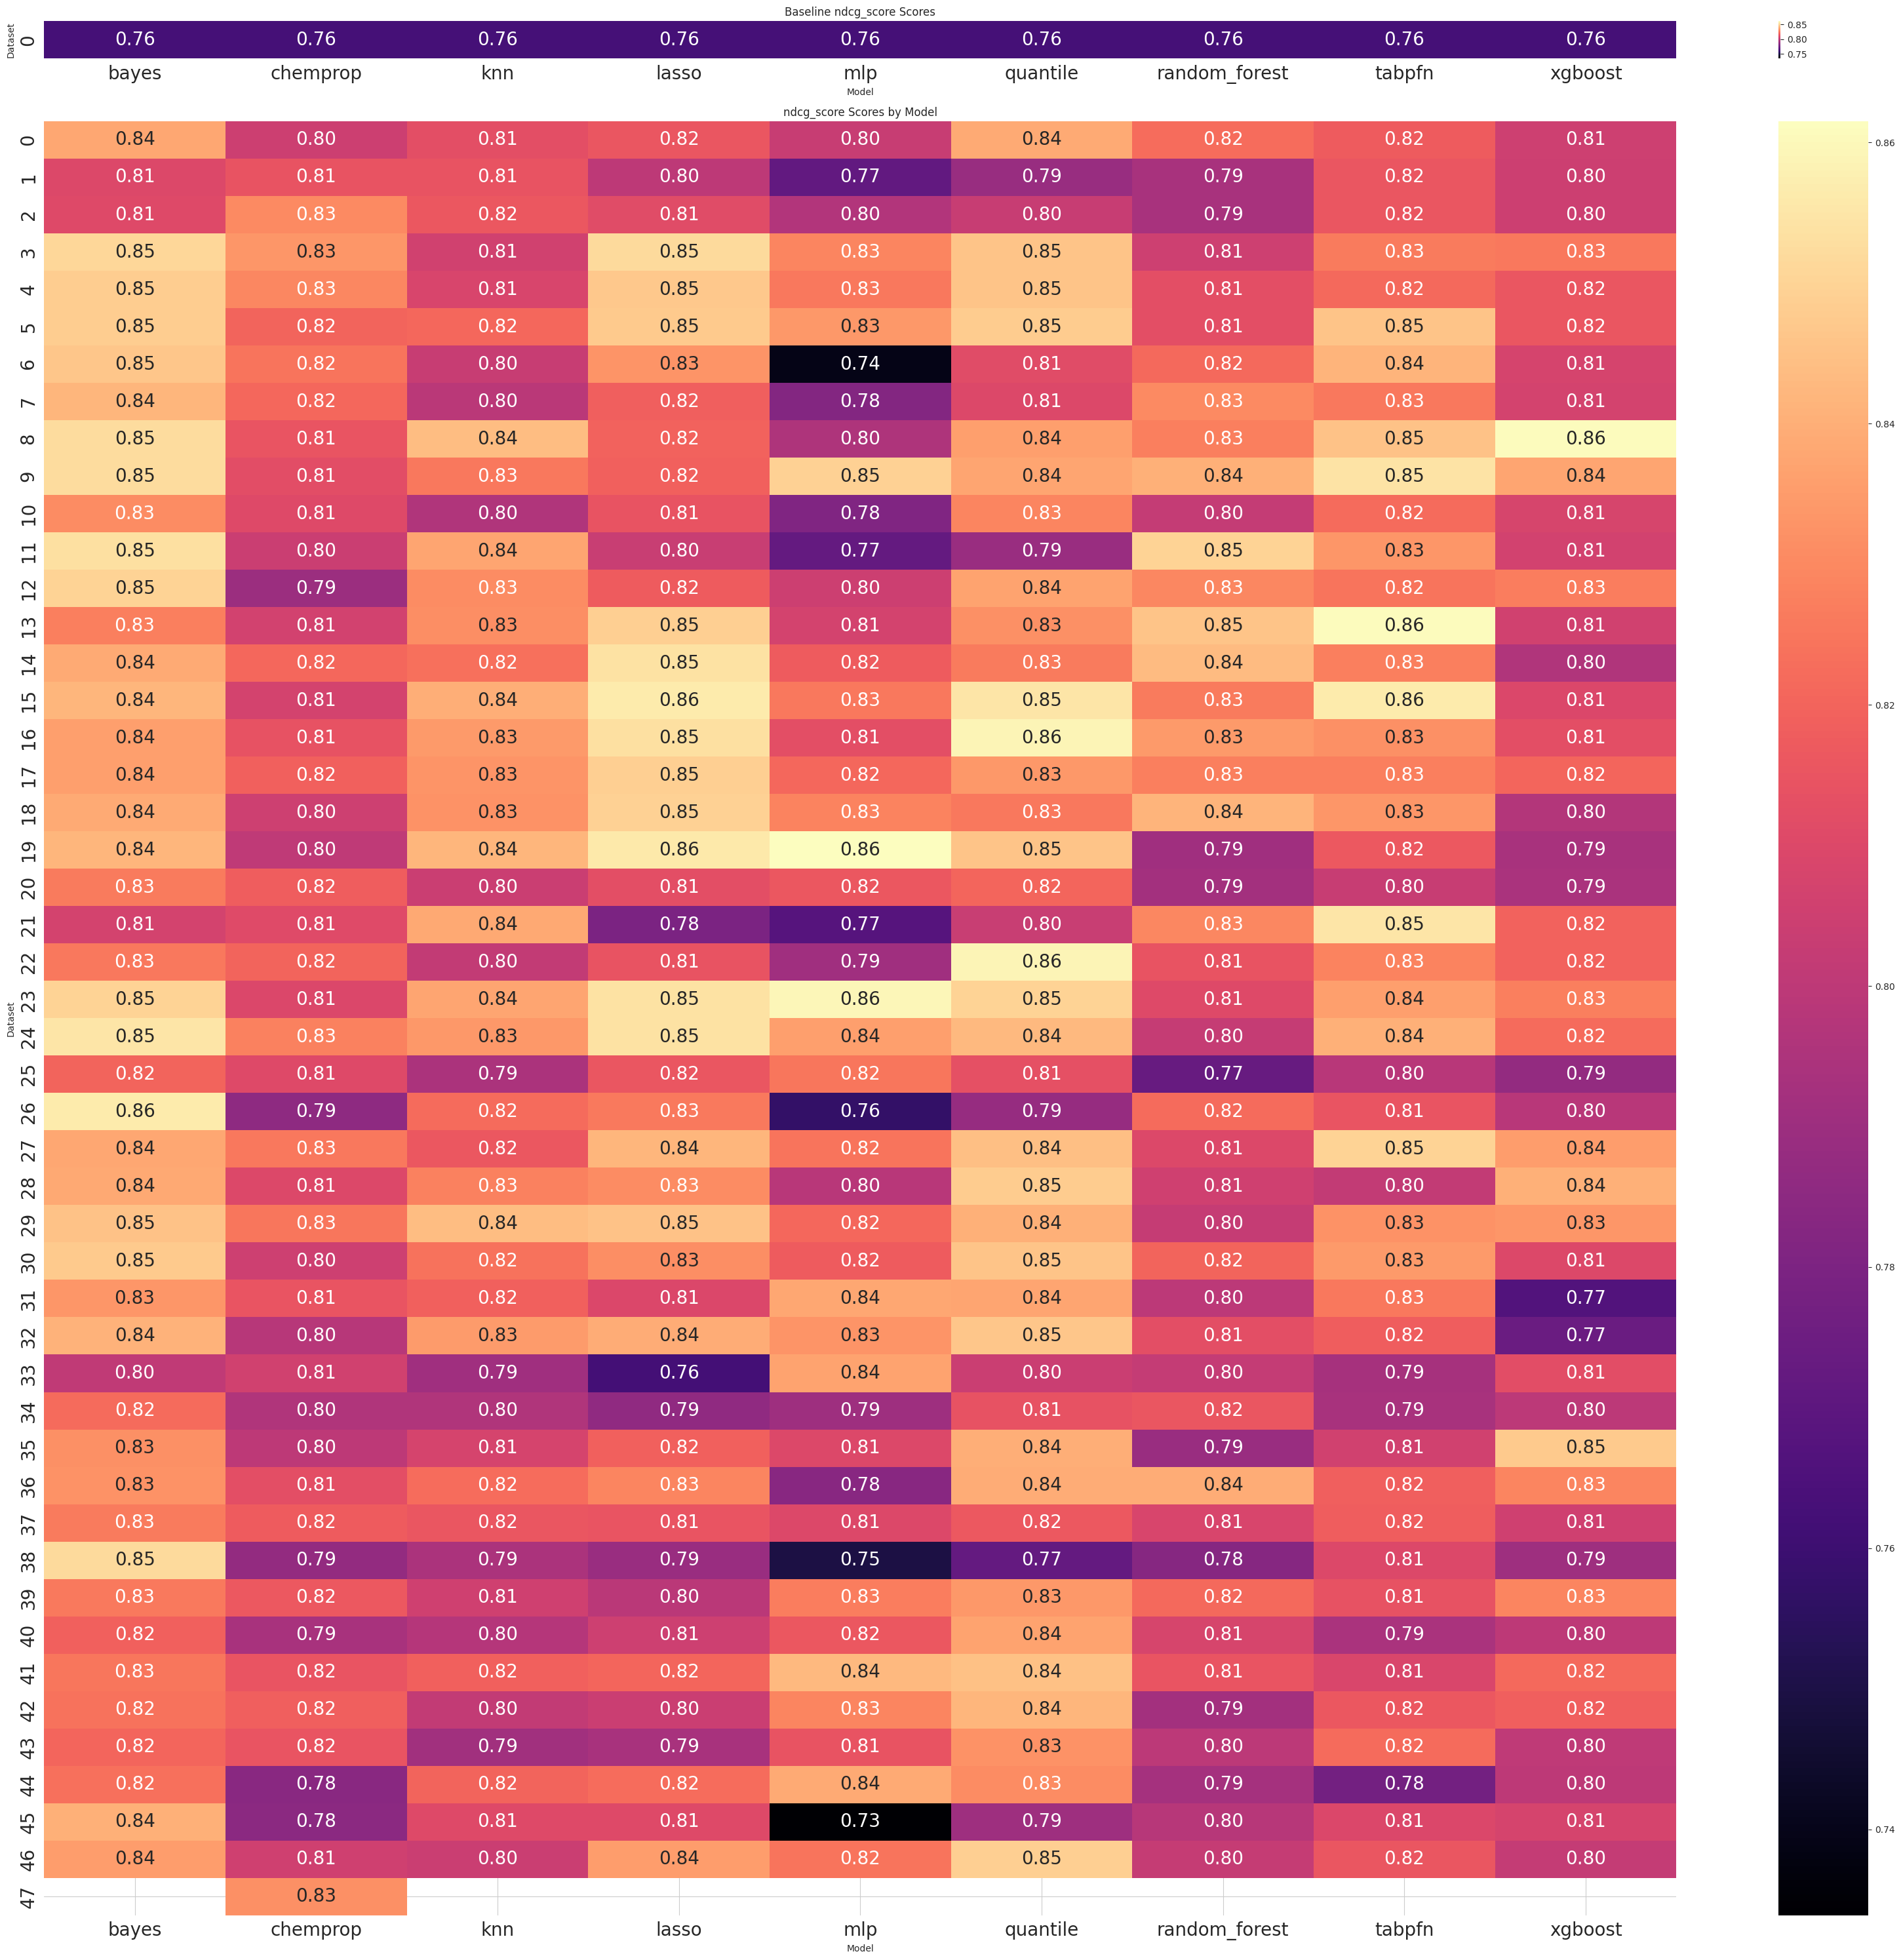

rmse


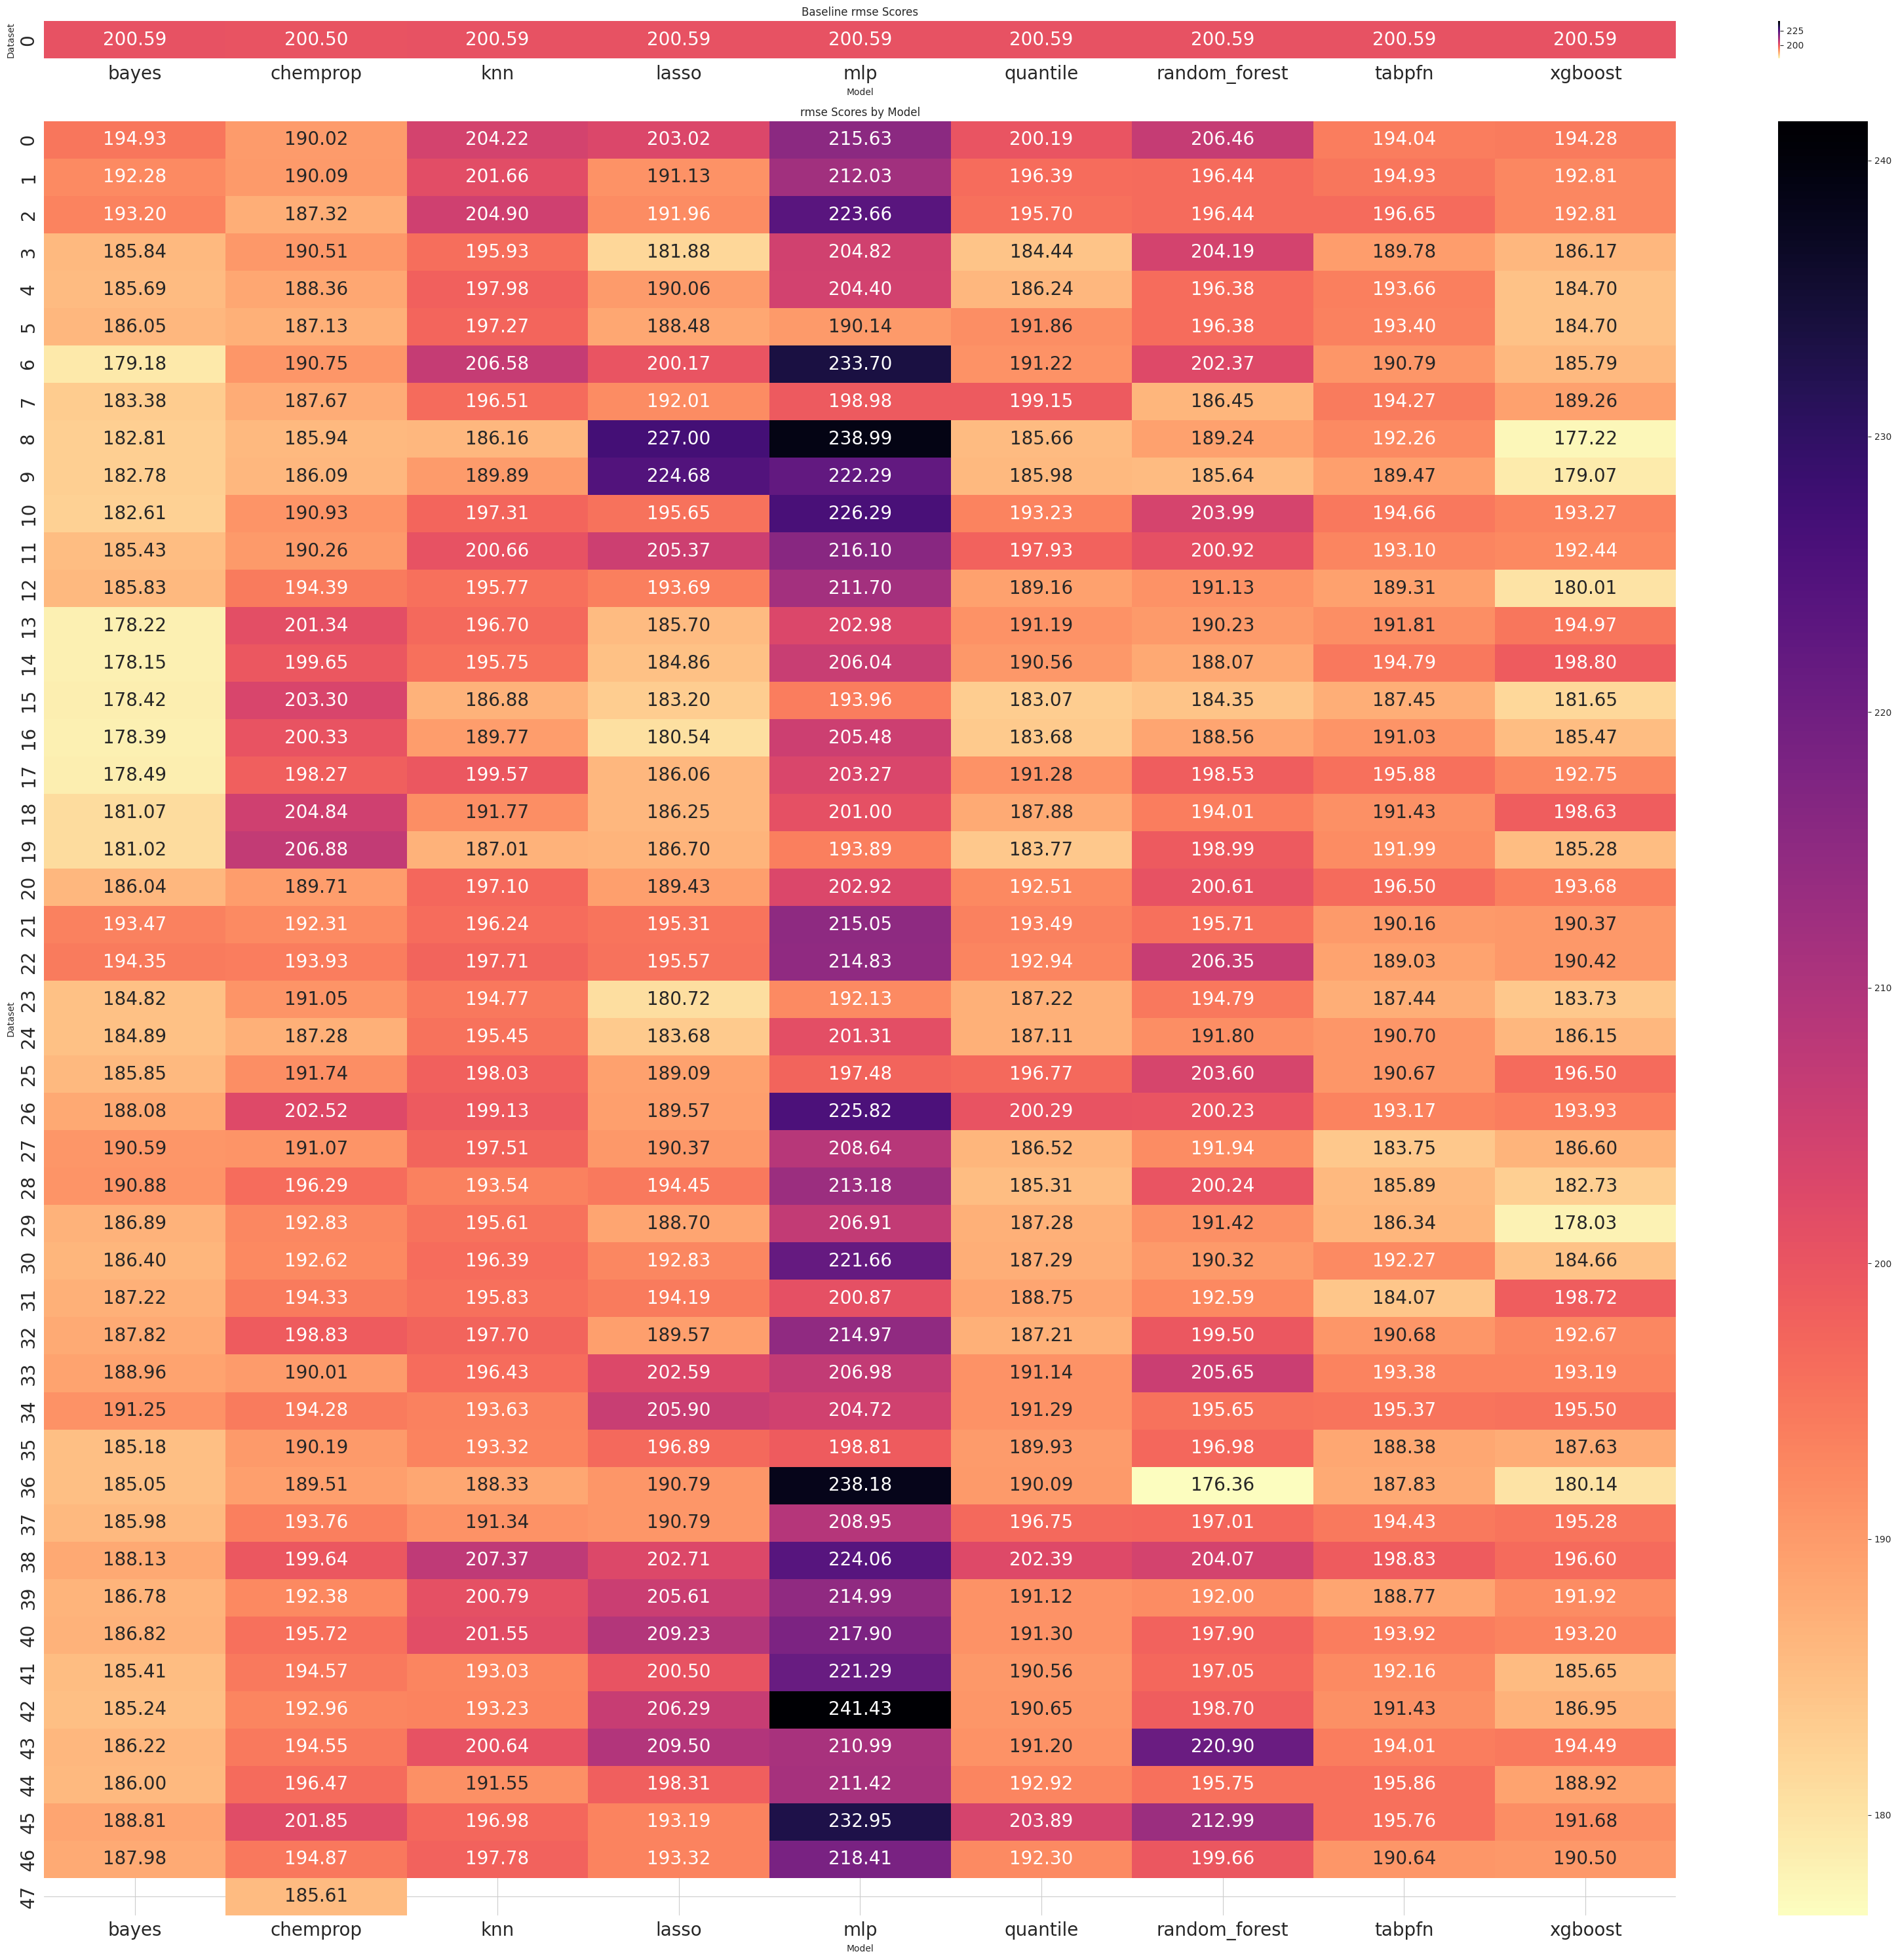

mae


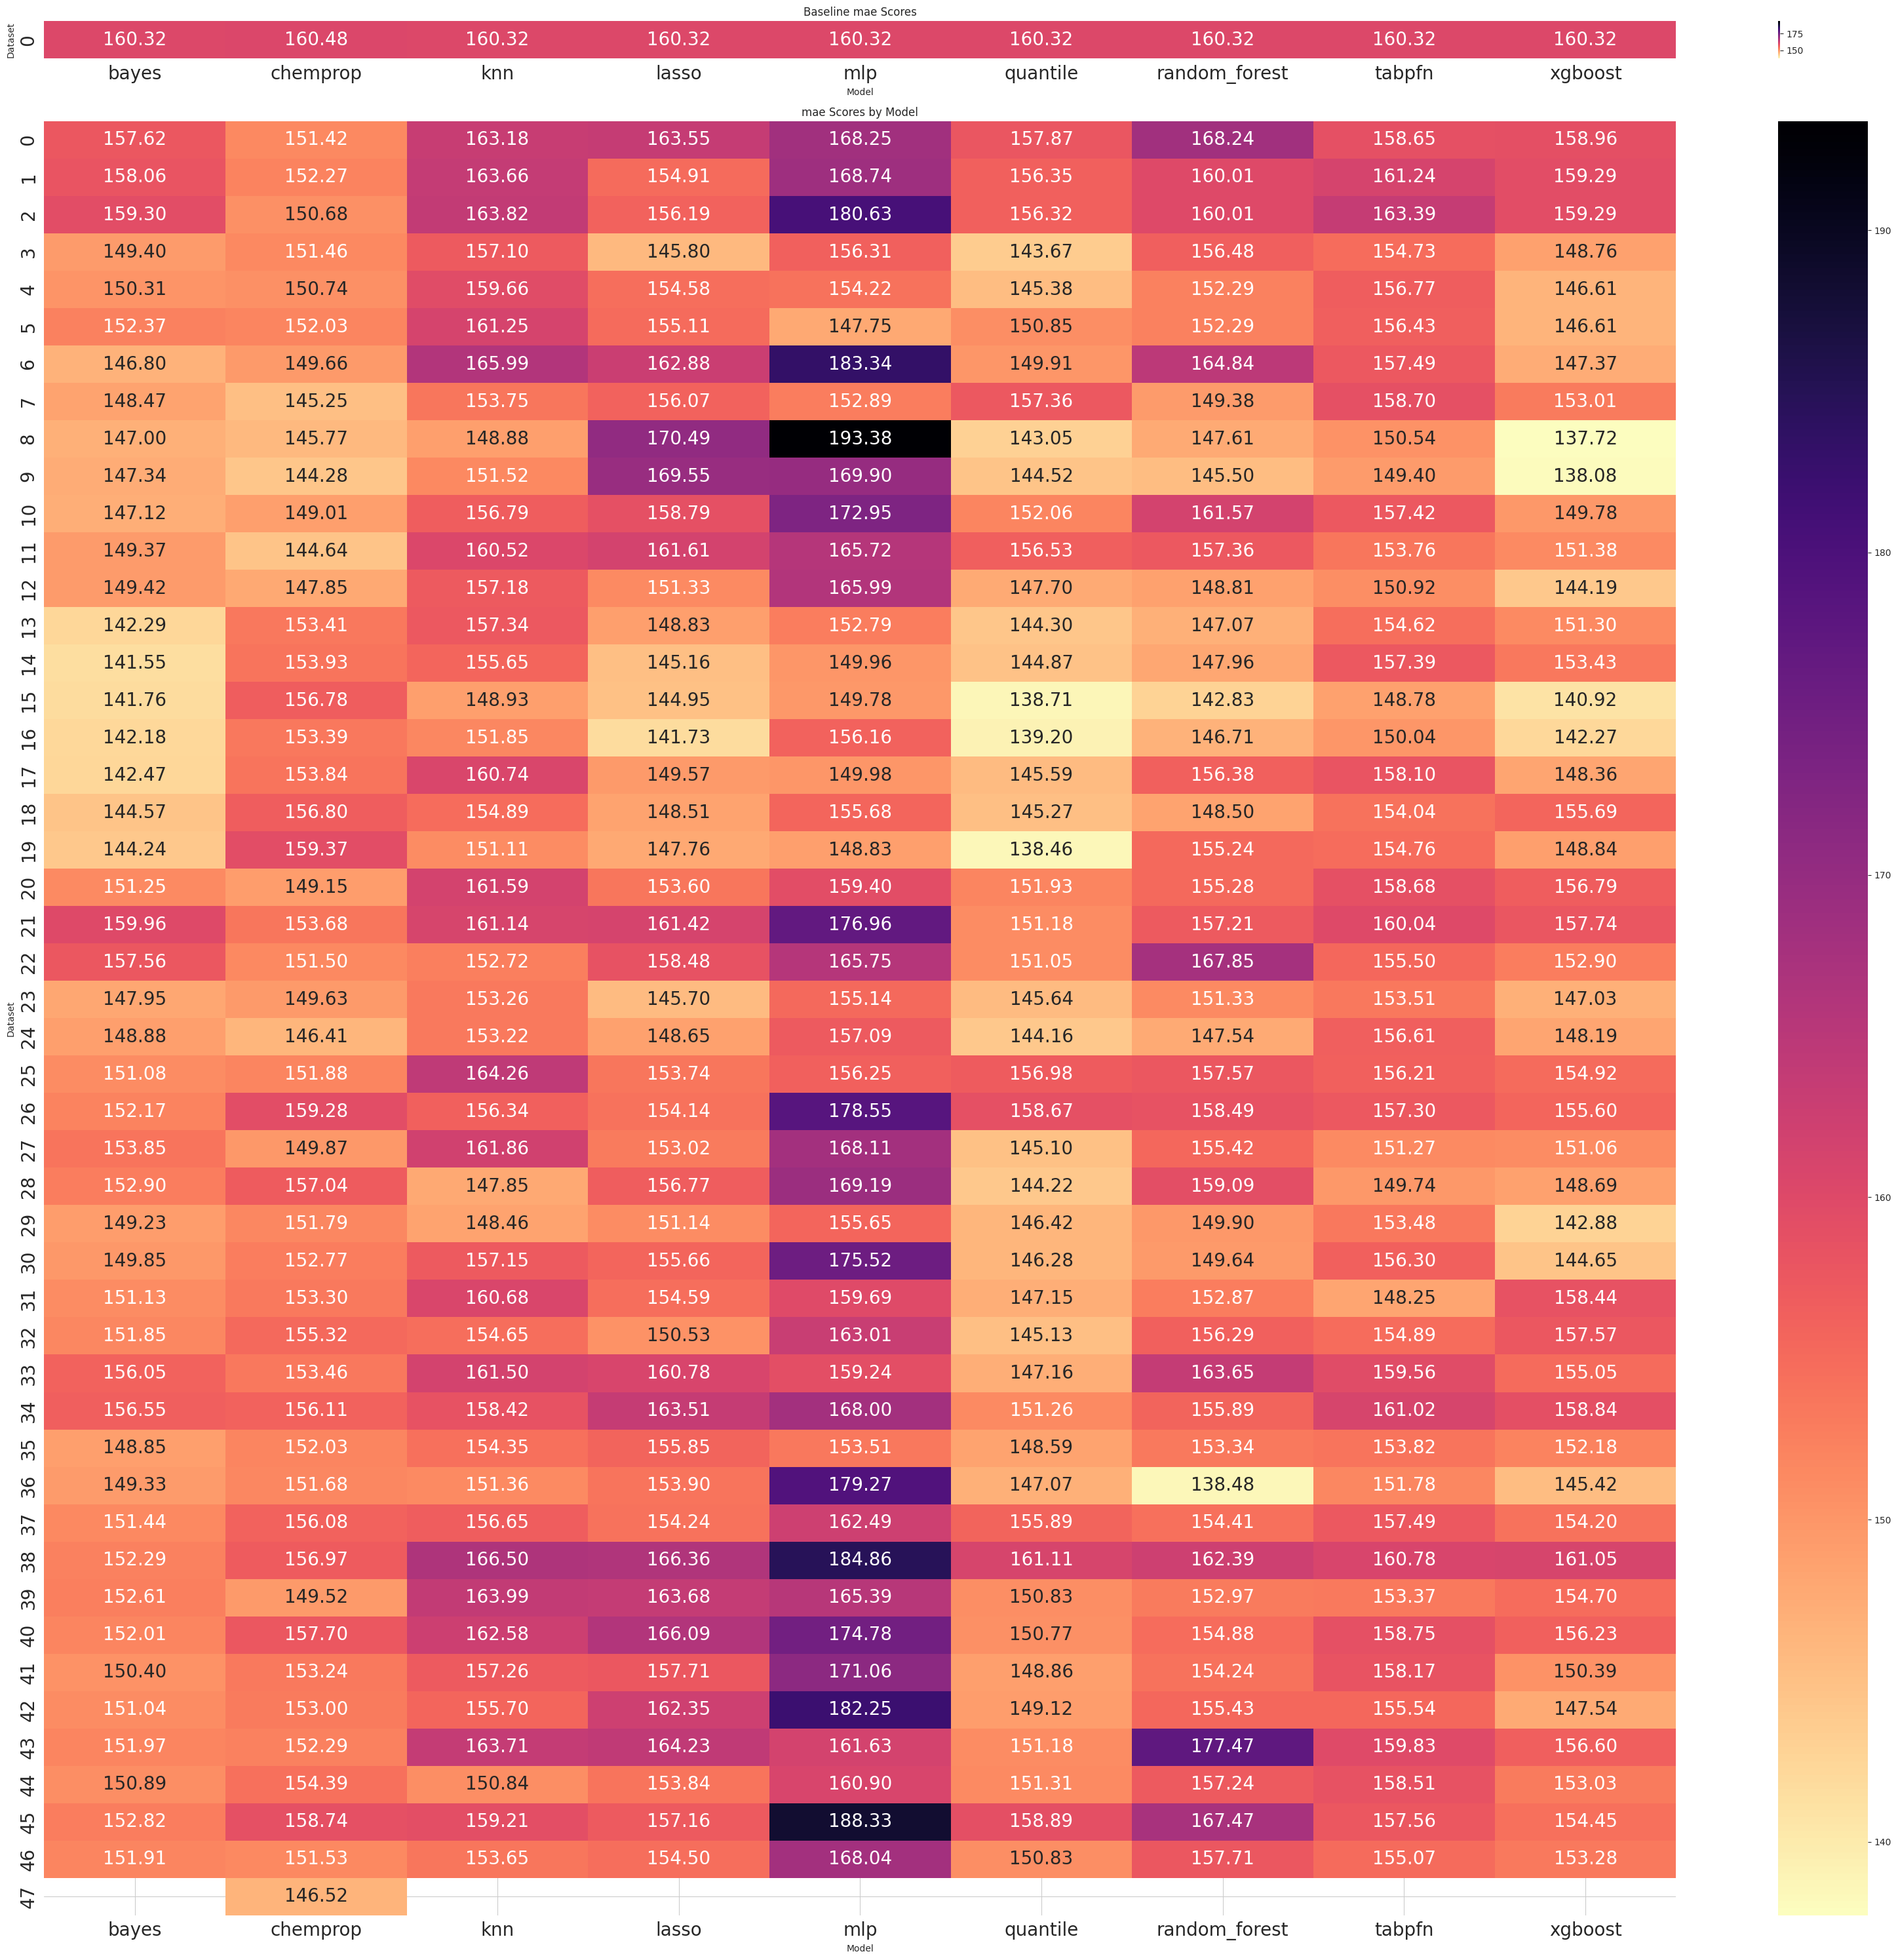

mape


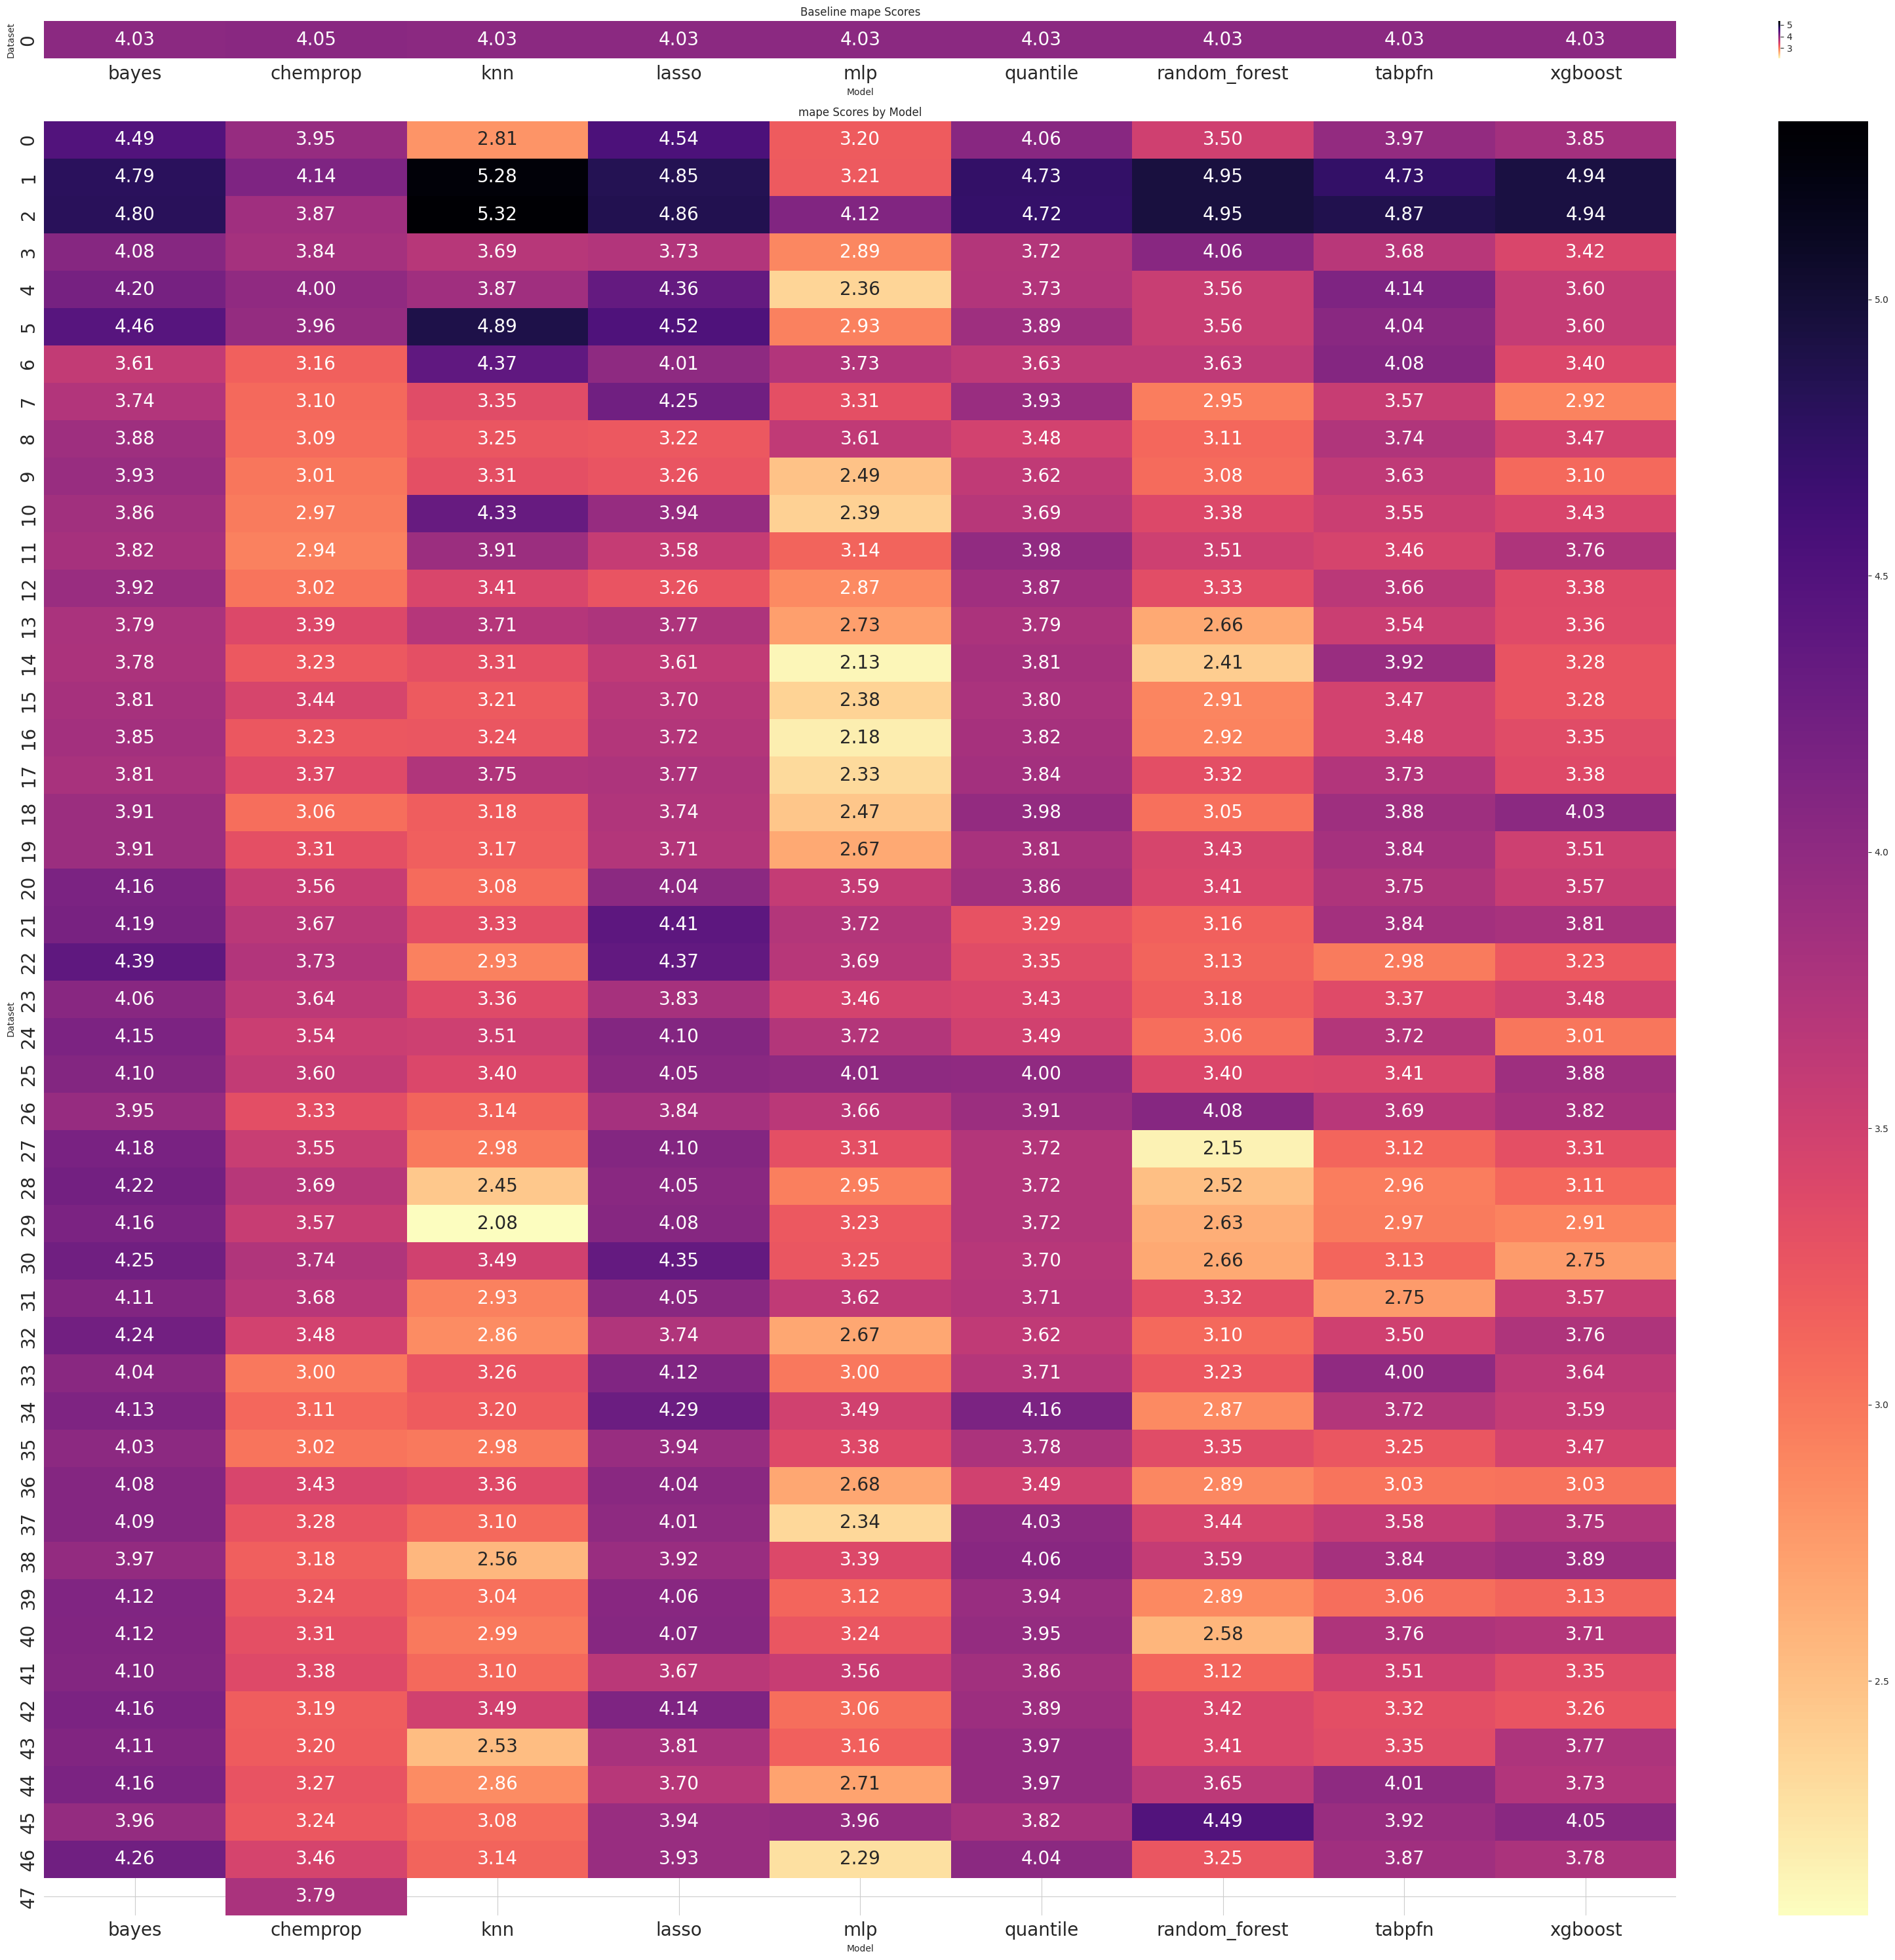

smape


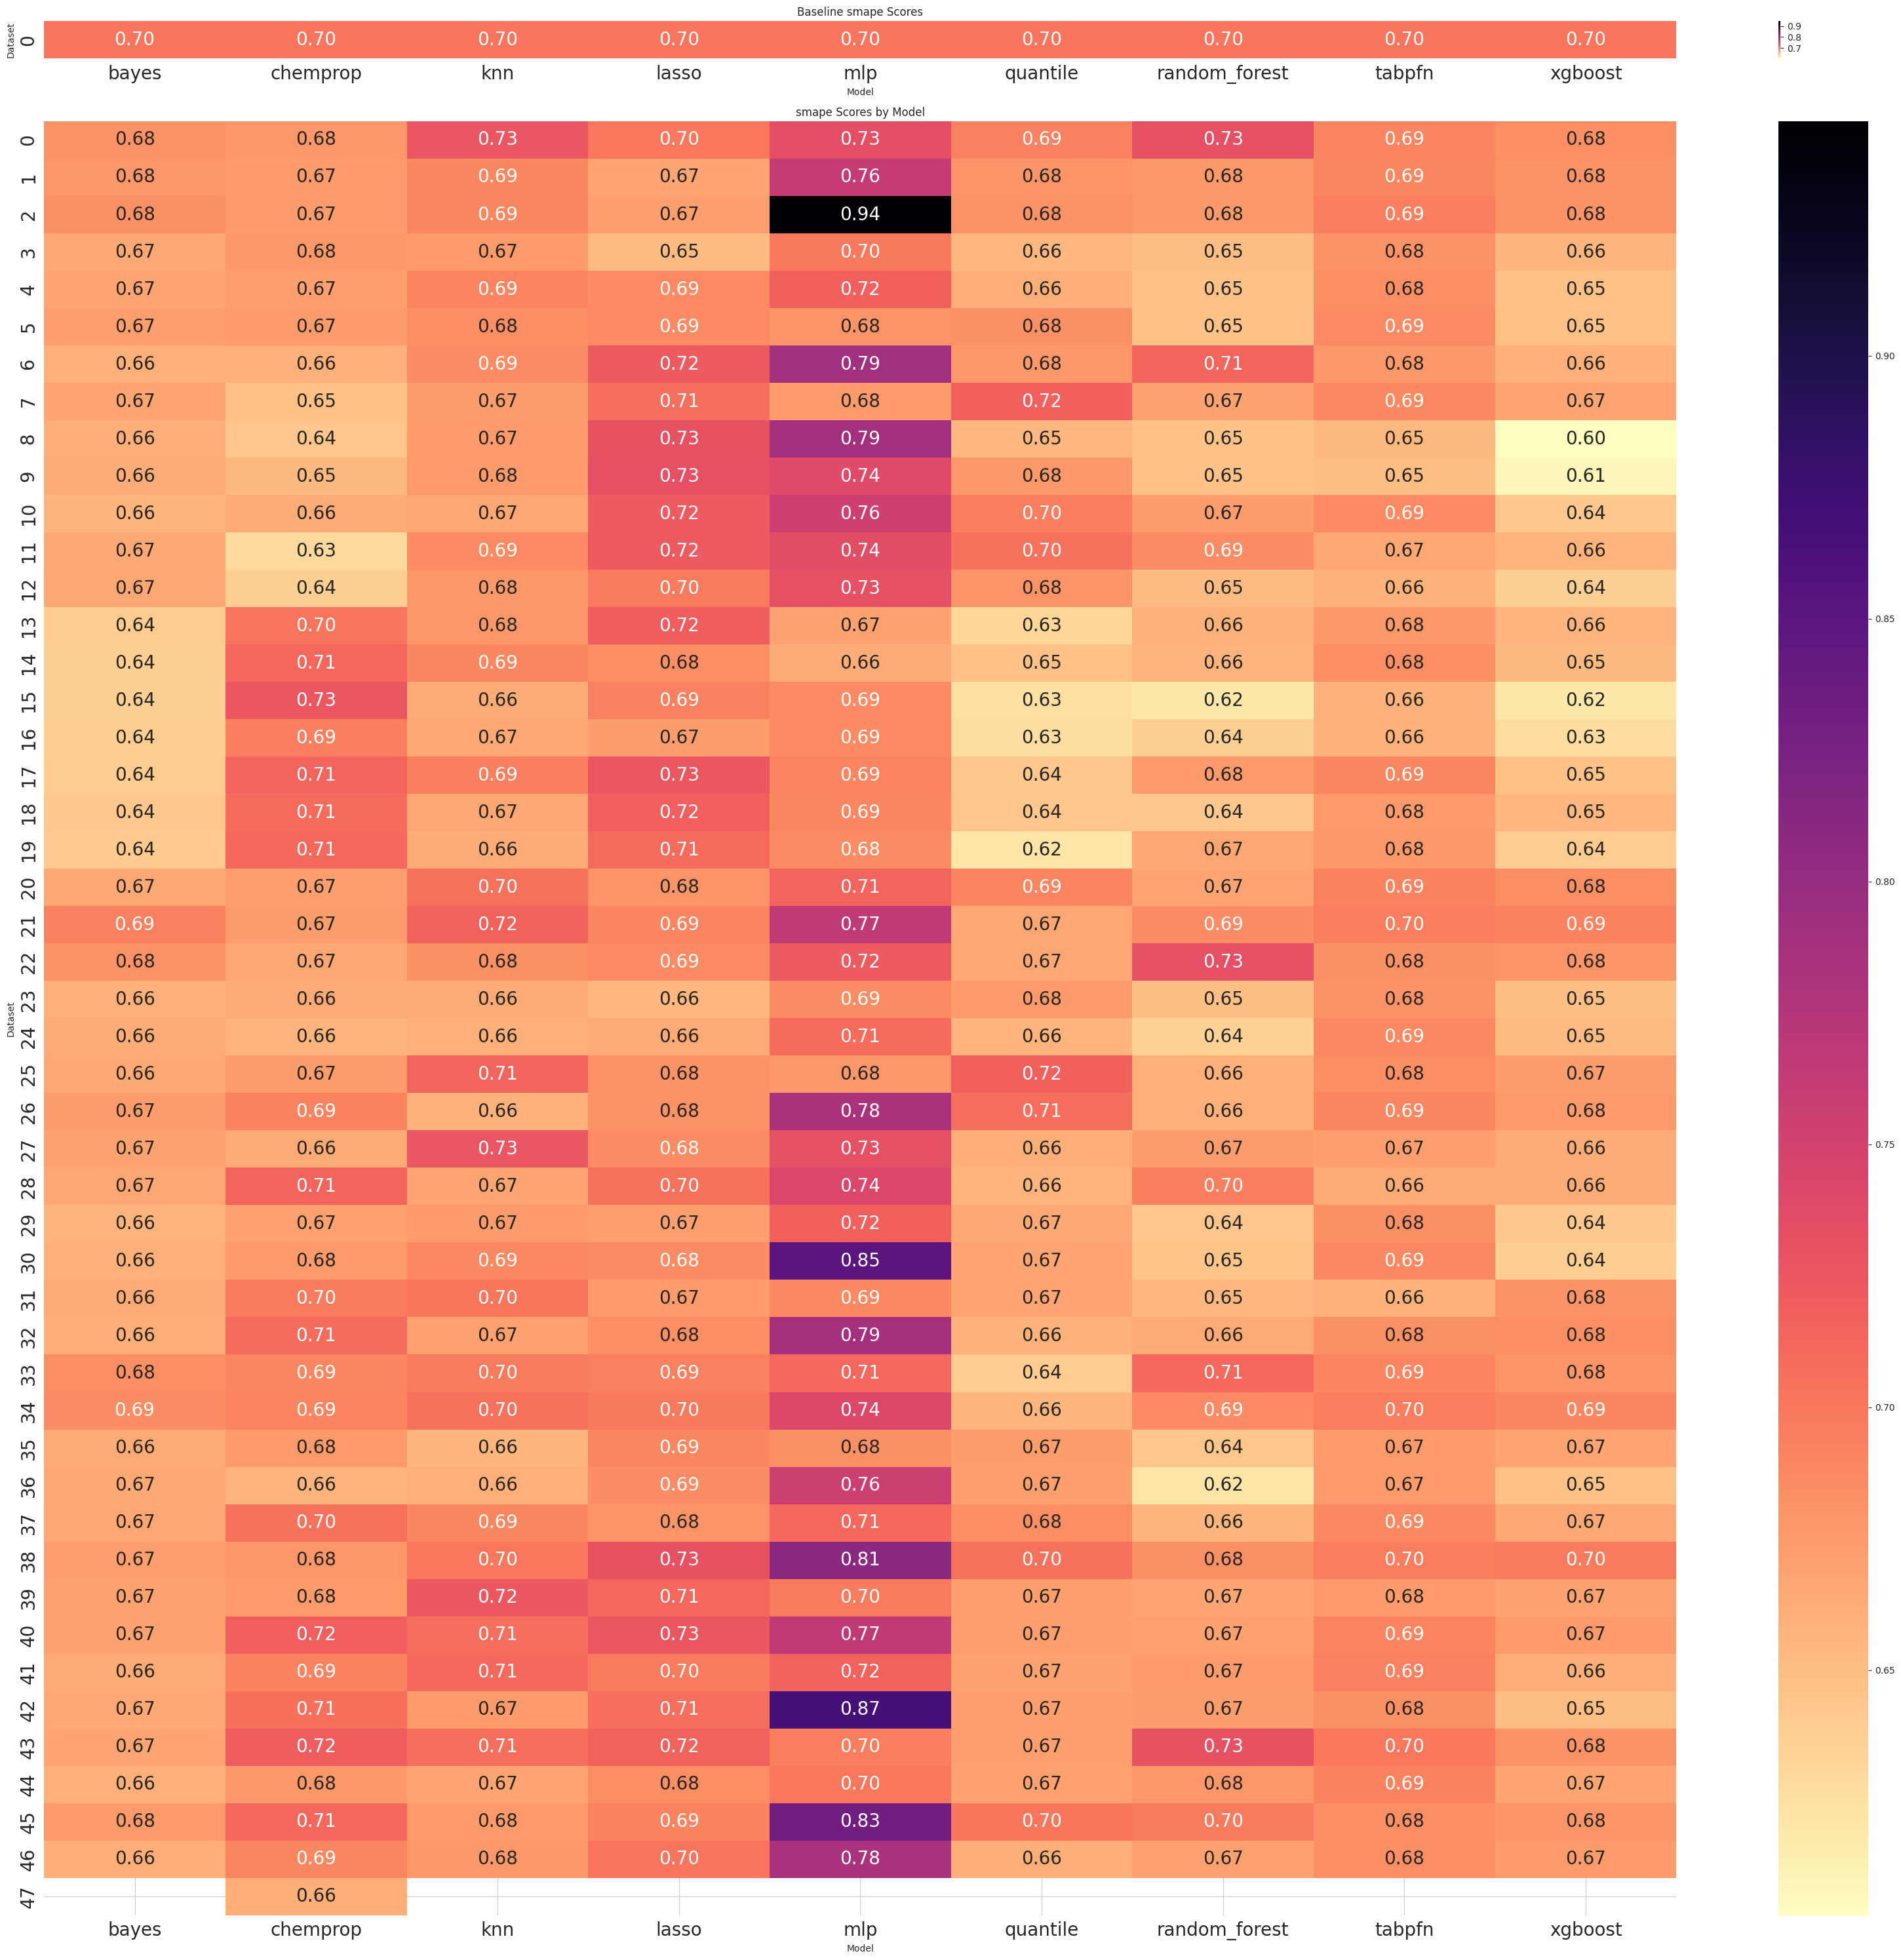

r2_score


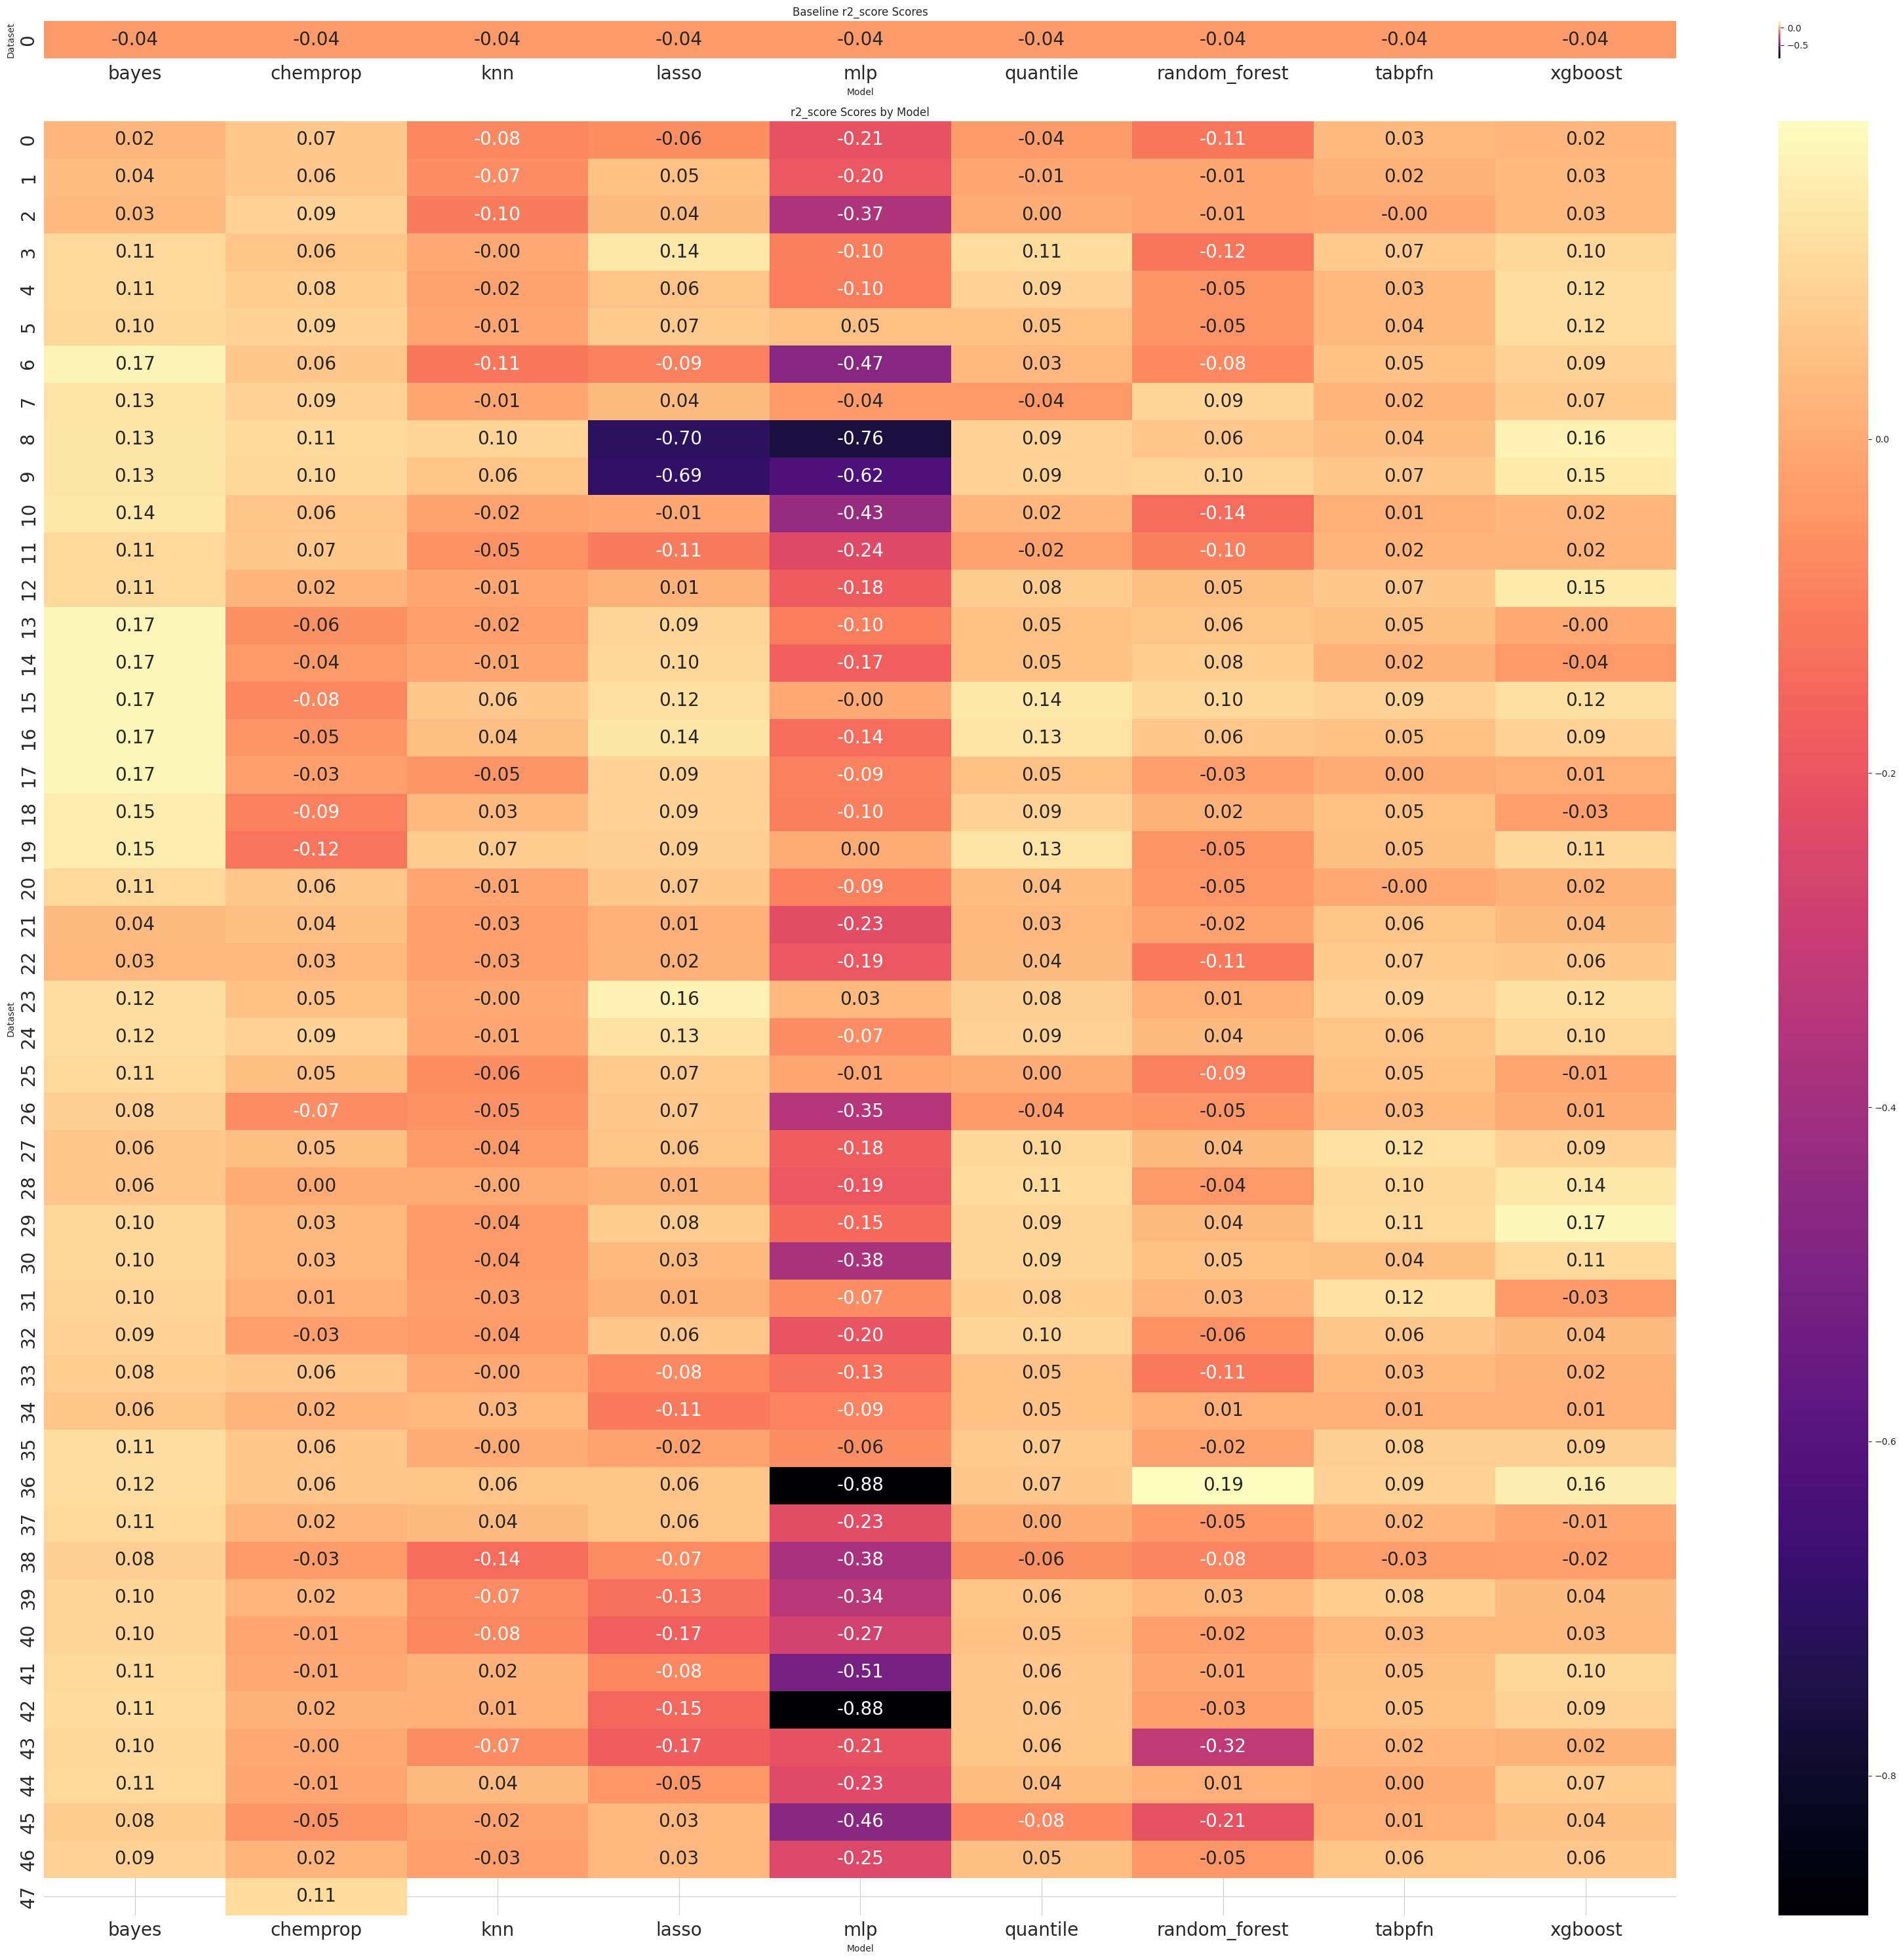

In [21]:
for metric in df_summary['Metric'].unique():
    if 'baseline' not in metric:
        print(metric)
        visualize_metric(df_summary, metric)

In [10]:
import pickle
import numpy as np

results_dir = "../../../results/trial_cof_ctf_rth_0.98_0.85"

scores_summary = {
    'pa': [],
    'smape': [],
    'r2_score': [],
    'rmse': [],
    'fold_id': [],
    'dataset': [],
    'model': []
}
for model in os.listdir(results_dir):
    model_dir = os.path.join(results_dir, model)
    for dataset in os.listdir(model_dir):
        dataset_dir = os.path.join(model_dir, dataset)
        result_file = os.path.join(dataset_dir, 'scores.pickle')
        try:
            with open(result_file, 'rb') as f:
                scores = pickle.load(f)
            scores_summary['pa'].extend(scores['pairwise_accuracy_score'])
            scores_summary['smape'].extend(scores['smape'])
            scores_summary['r2_score'].extend(scores['r2_score'])
            scores_summary['rmse'].extend(scores['rmse'])
            scores_summary['fold_id'].extend(np.arange(0, len(scores['pairwise_accuracy_score'])))
            scores_summary['dataset'].extend([dataset] * len(scores['pairwise_accuracy_score']))
            scores_summary['model'].extend([model] * len(scores['pairwise_accuracy_score']))
        except FileNotFoundError:
            print(f"File not found: {result_file}")
            continue
scores_summary = pd.DataFrame(scores_summary)
scores_summary.head()

,pa,smape,r2_score,rmse,fold_id,dataset,model
0,0.619048,0.376927,0.096832,162.565920,0,features_rth_1.0_current_flat_no_symdescriptor...,xgboost
1,0.549451,0.346705,-0.278449,190.461005,1,features_rth_1.0_current_flat_no_symdescriptor...,xgboost
2,0.485714,0.518956,-0.788604,231.723398,2,features_rth_1.0_current_flat_no_symdescriptor...,xgboost
3,0.461538,0.468429,-0.674462,216.034780,3,features_rth_1.0_current_flat_no_symdescriptor...,xgboost
4,0.663462,0.402269,0.077641,176.765580,4,features_rth_1.0_current_flat_no_symdescriptor...,xgboost


In [11]:
current_files = scores_summary[scores_summary['dataset'].str.contains('current')]
old_files = scores_summary[scores_summary['dataset'].str.contains('old')]

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_dataframe(df):
    metrics = ['pa', 'smape', 'r2_score', 'rmse']
    df_group = df.groupby(df['model'])
    for (model, d) in df_group:
        fig, axes = plt.subplots(2, 2, figsize=(24, 12))
        for i, m in enumerate(metrics):
            ax = axes.flatten()[i]
            sns.barplot(d, x='fold_id', y=m, ax=ax, hue='dataset', palette='muted', alpha=1)
            ax.legend_.remove()
            ax.set_title(f'{m} Scores for {model}')
        plt.show()

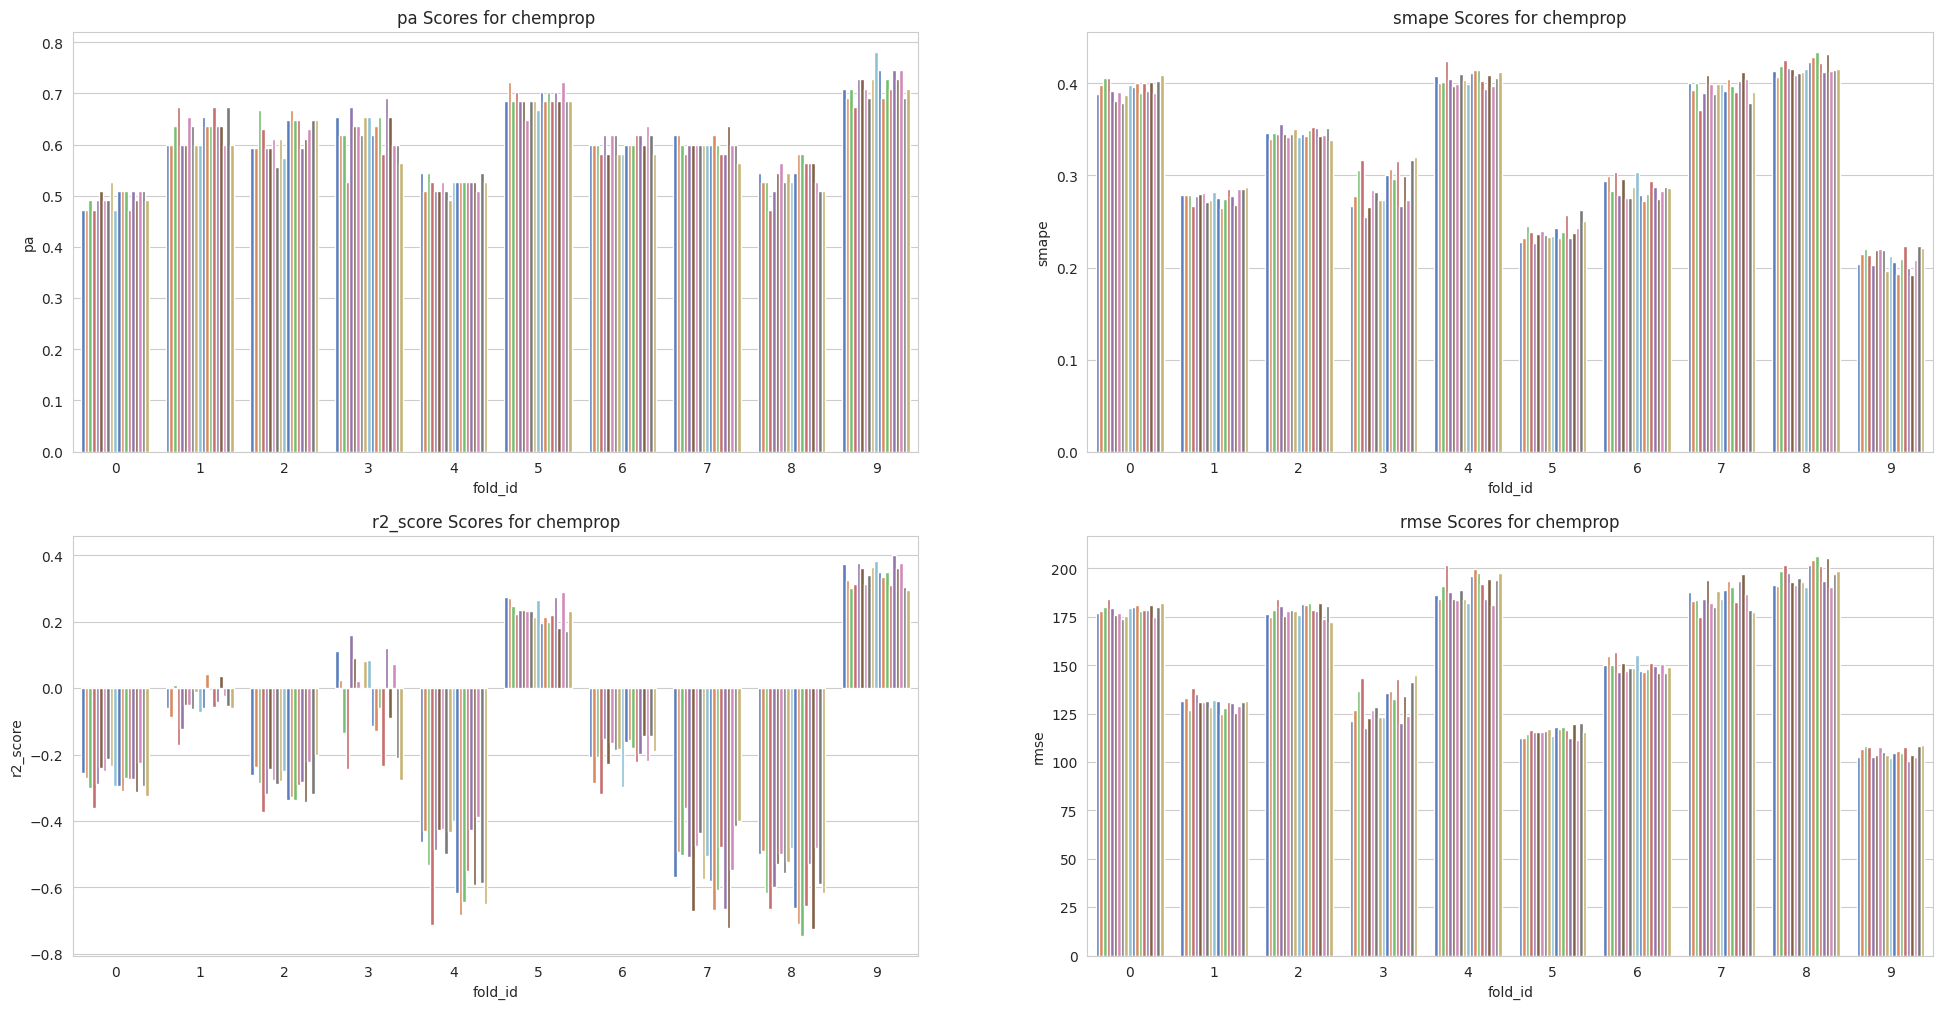

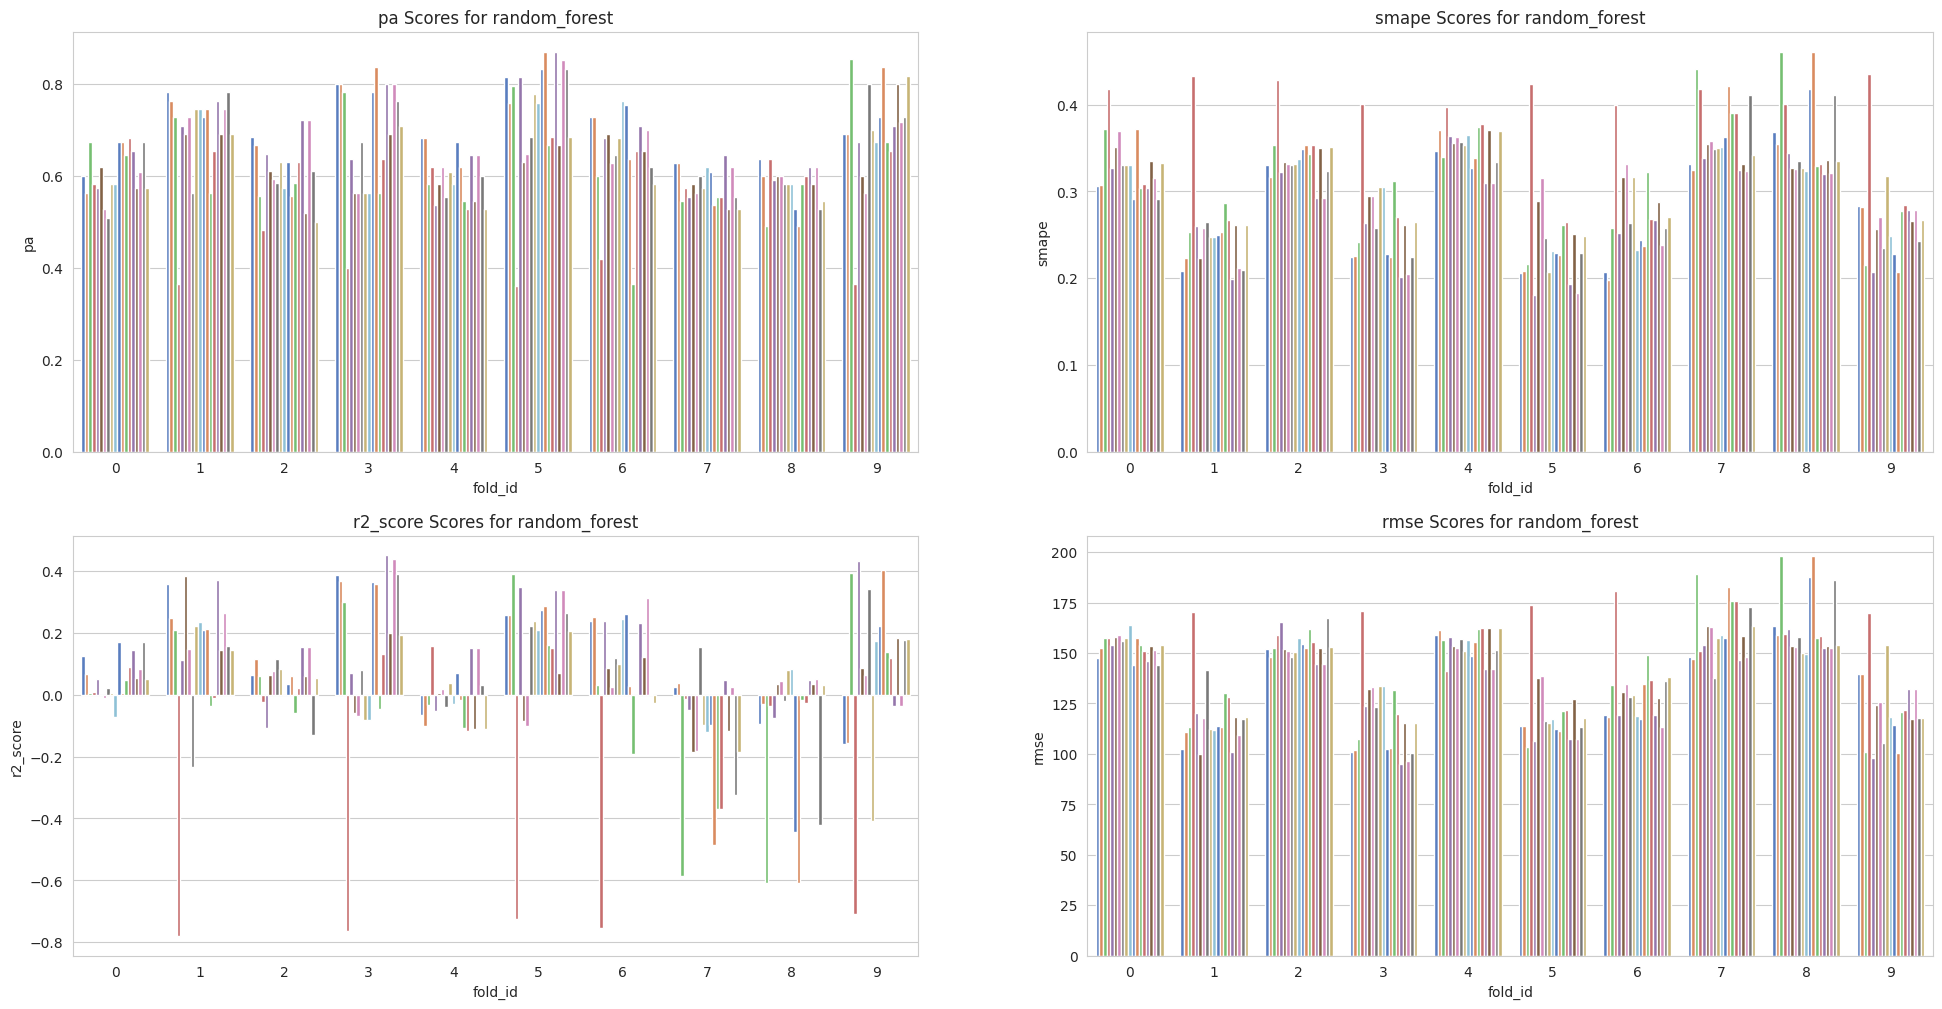

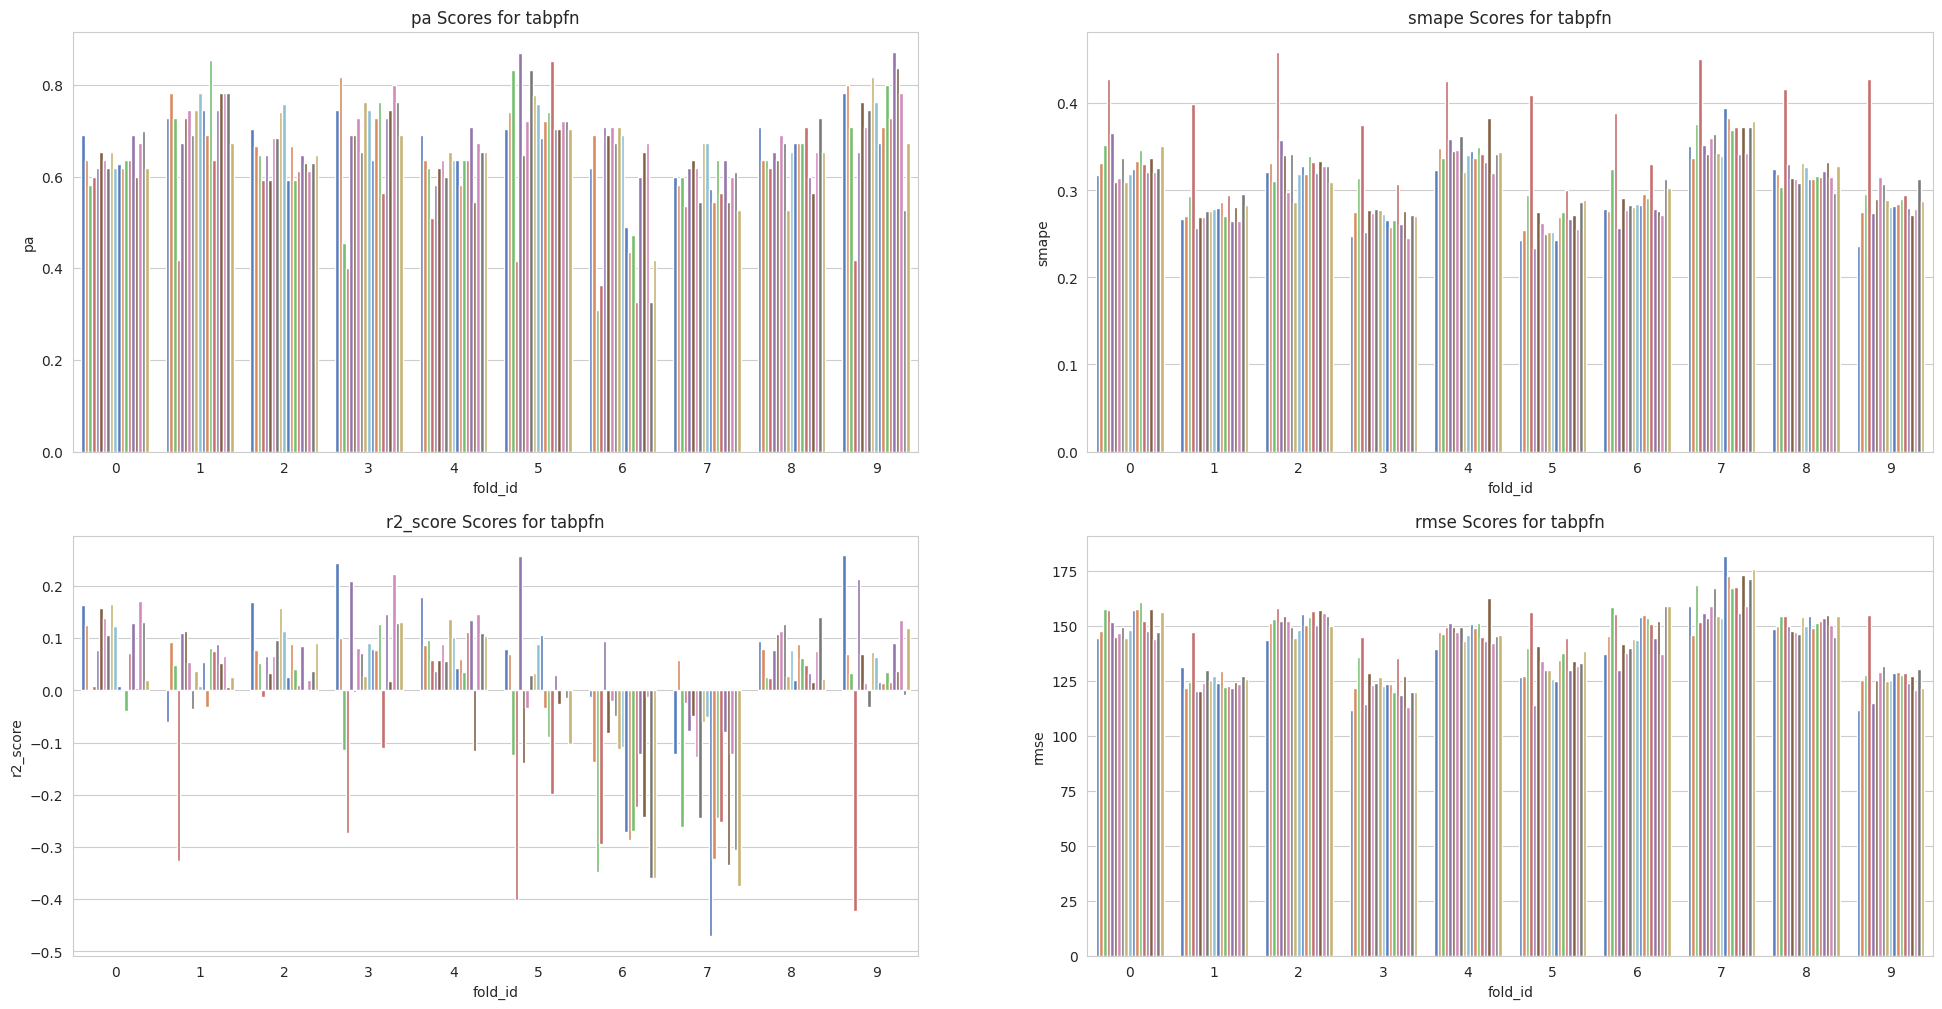

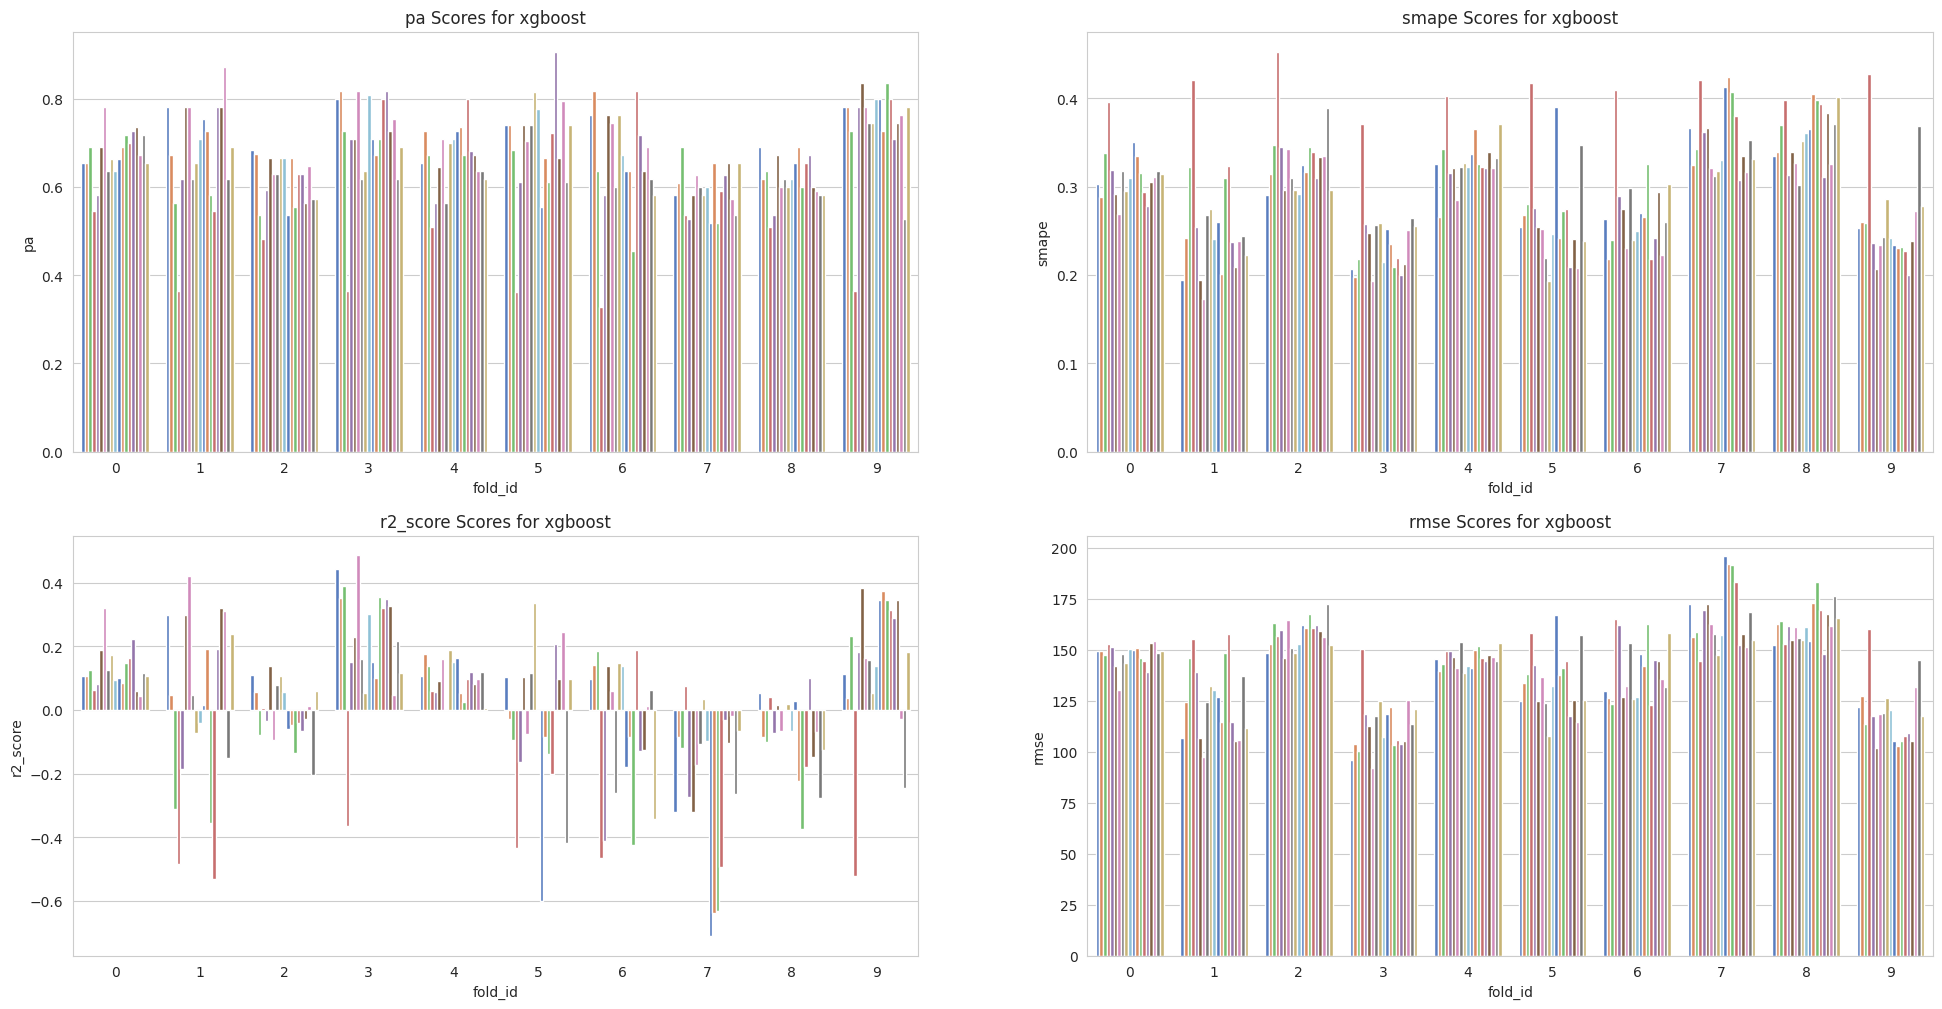

In [26]:
visualize_dataframe(old_files)

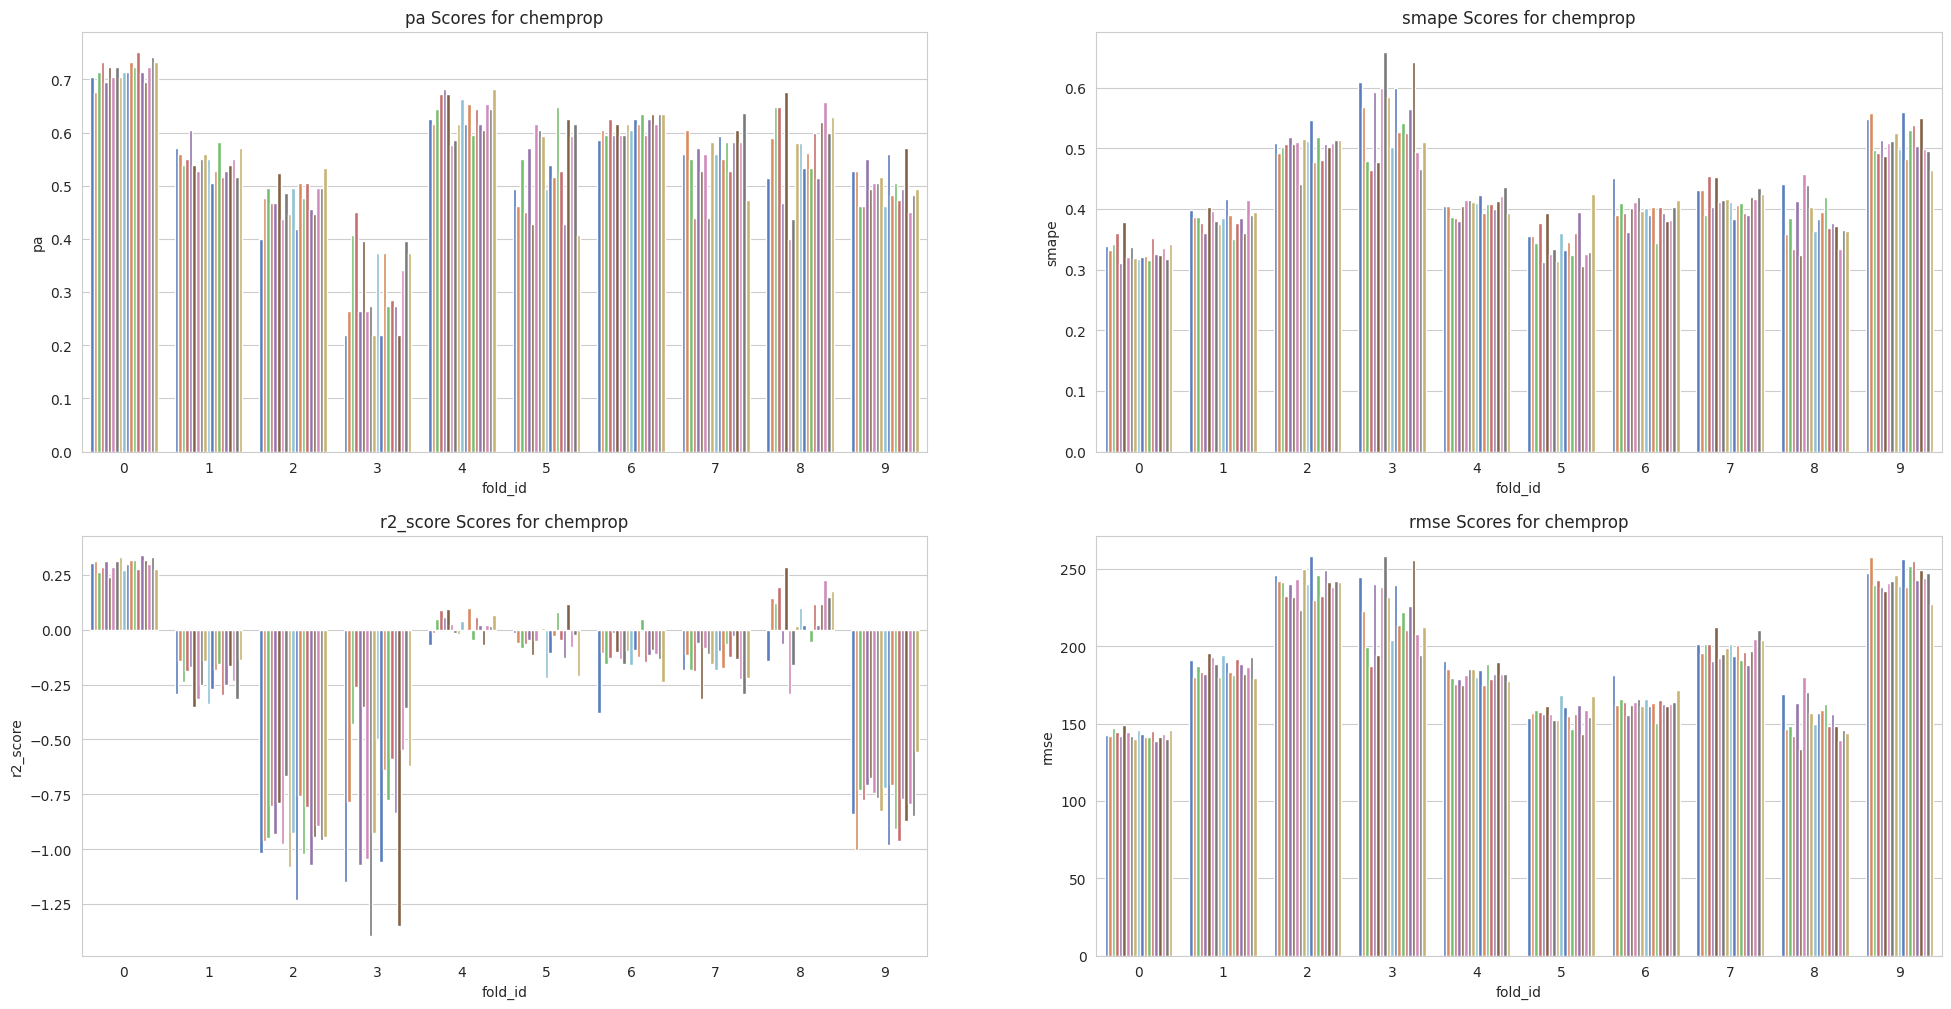

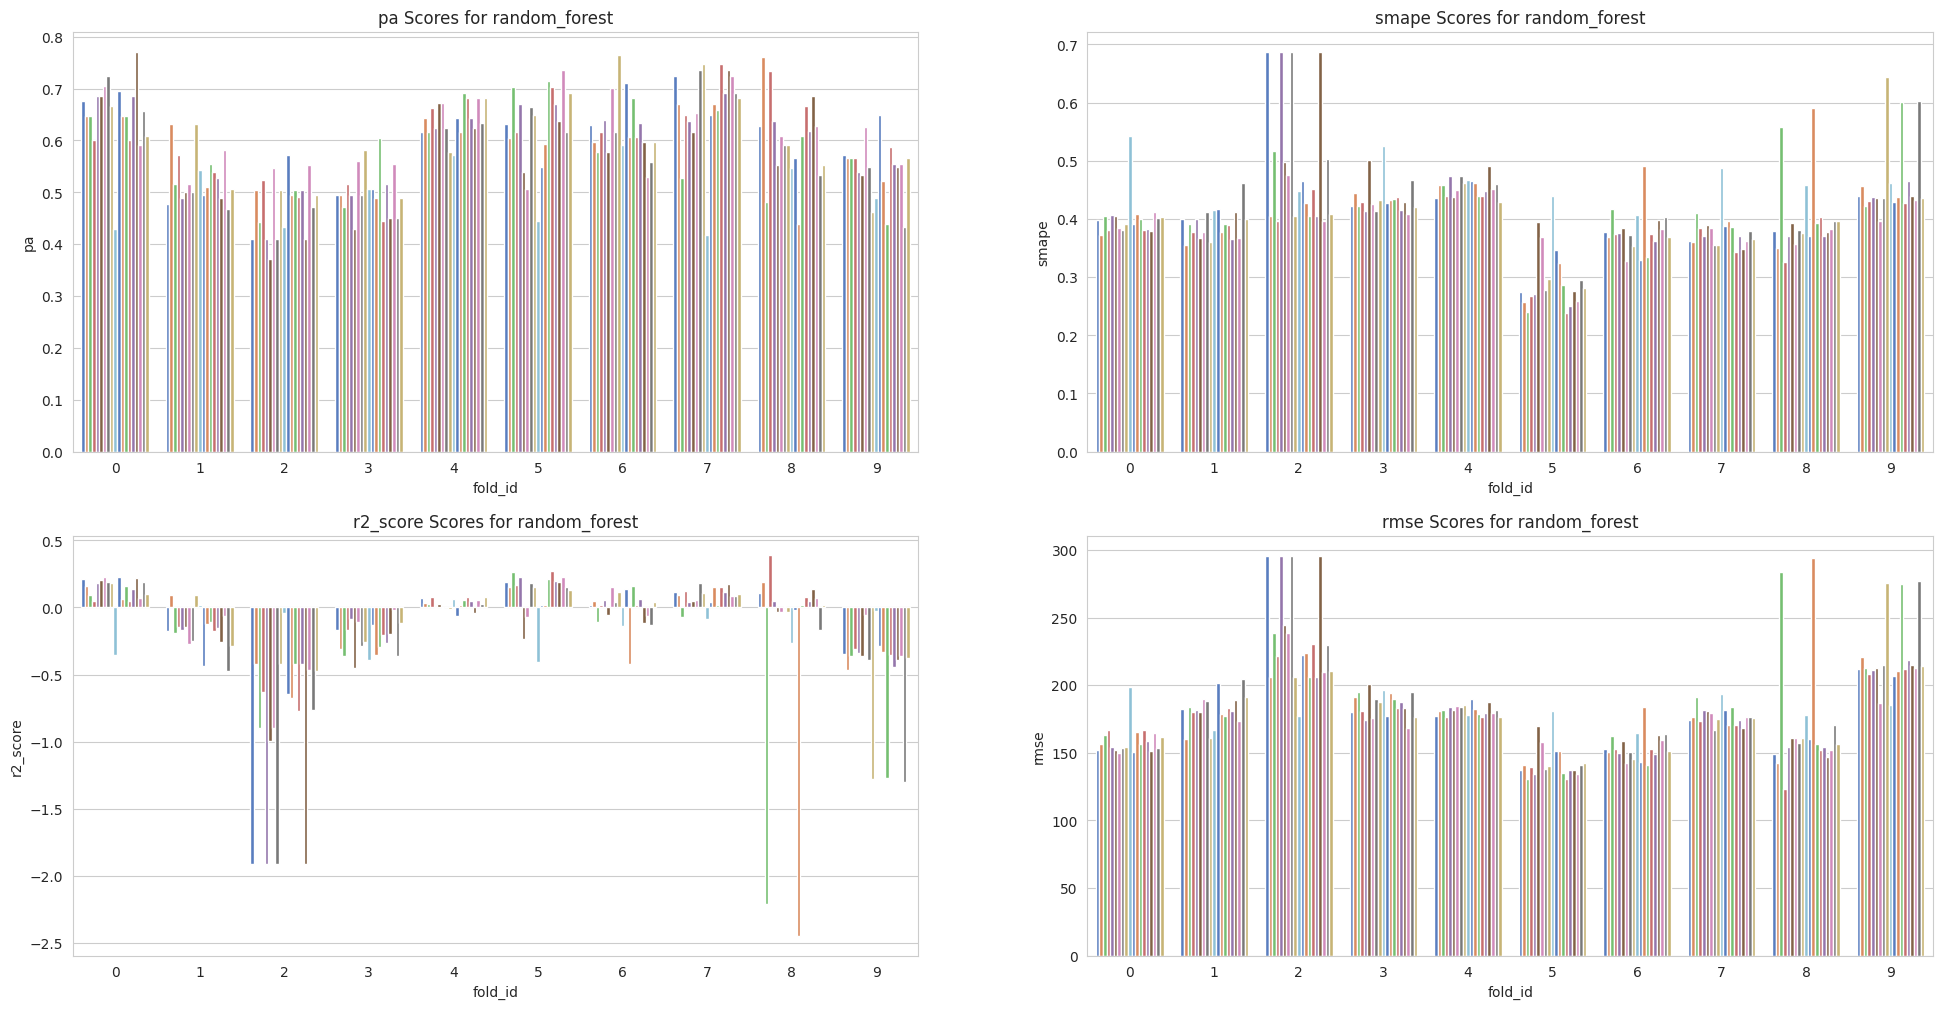

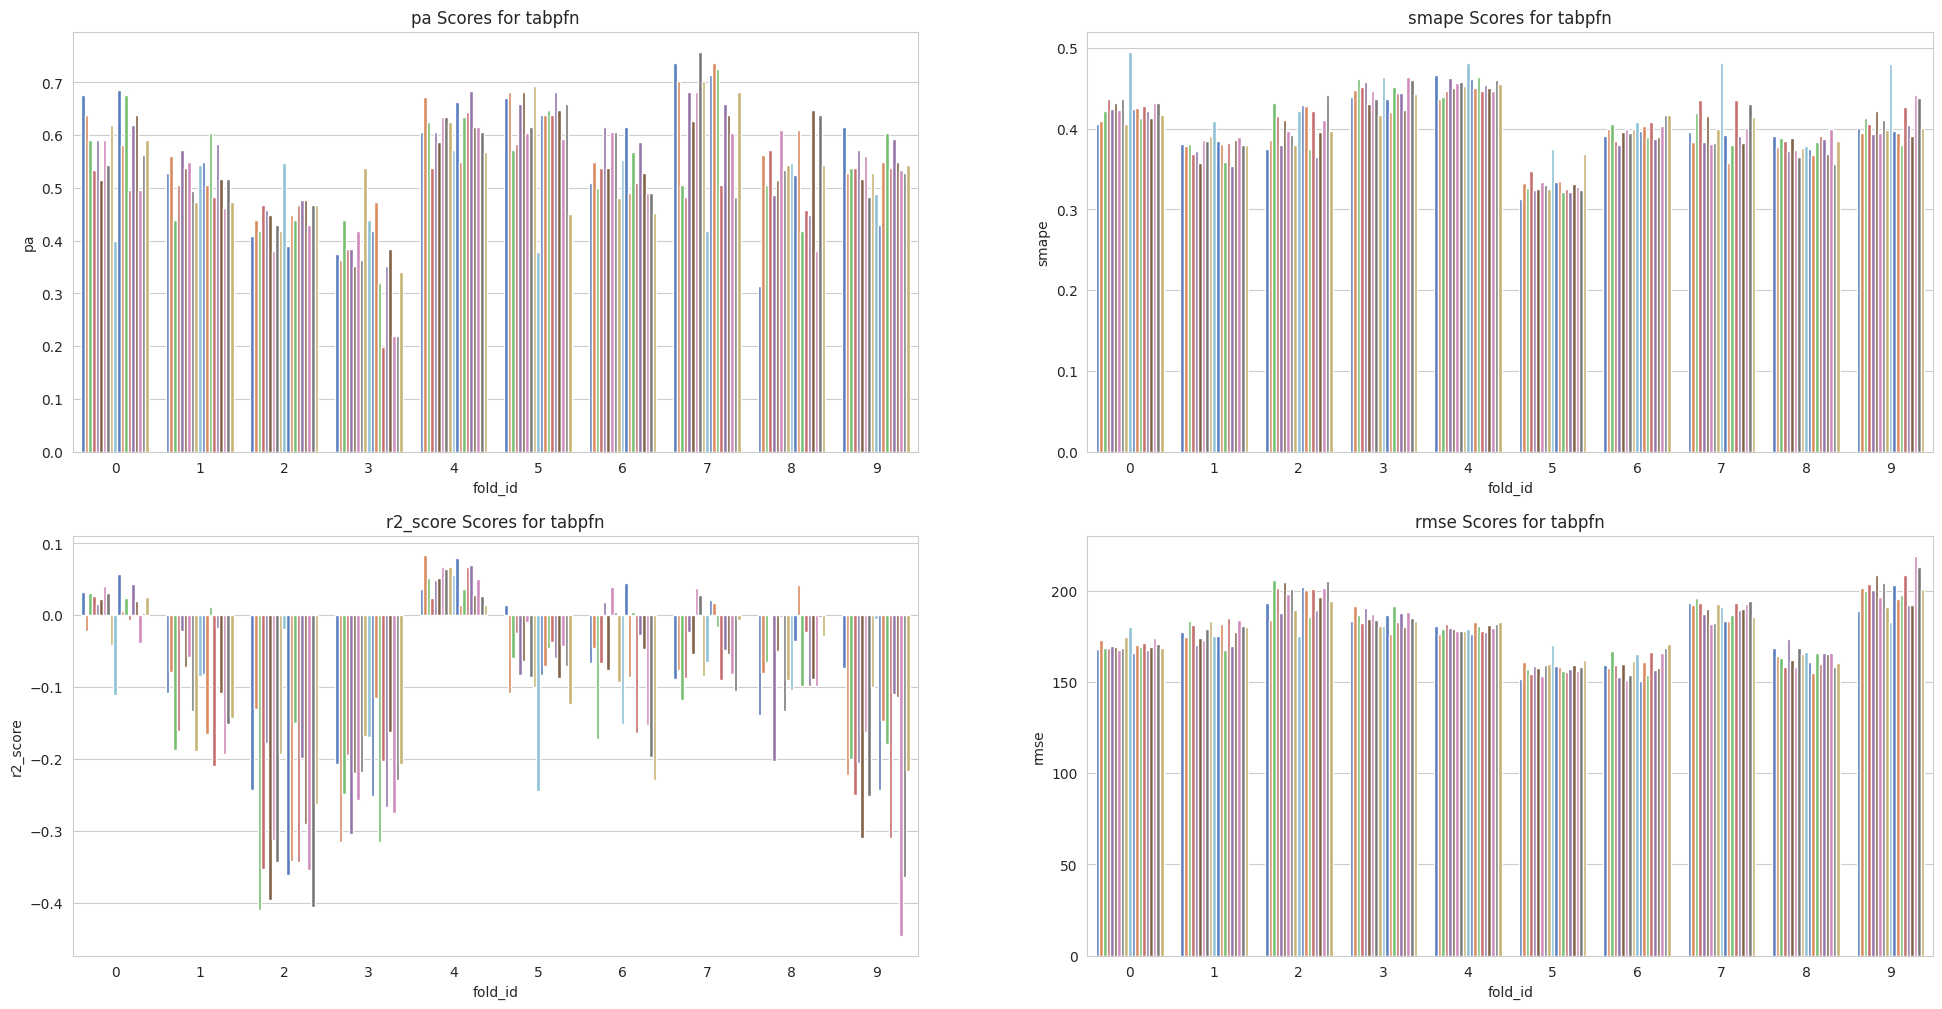

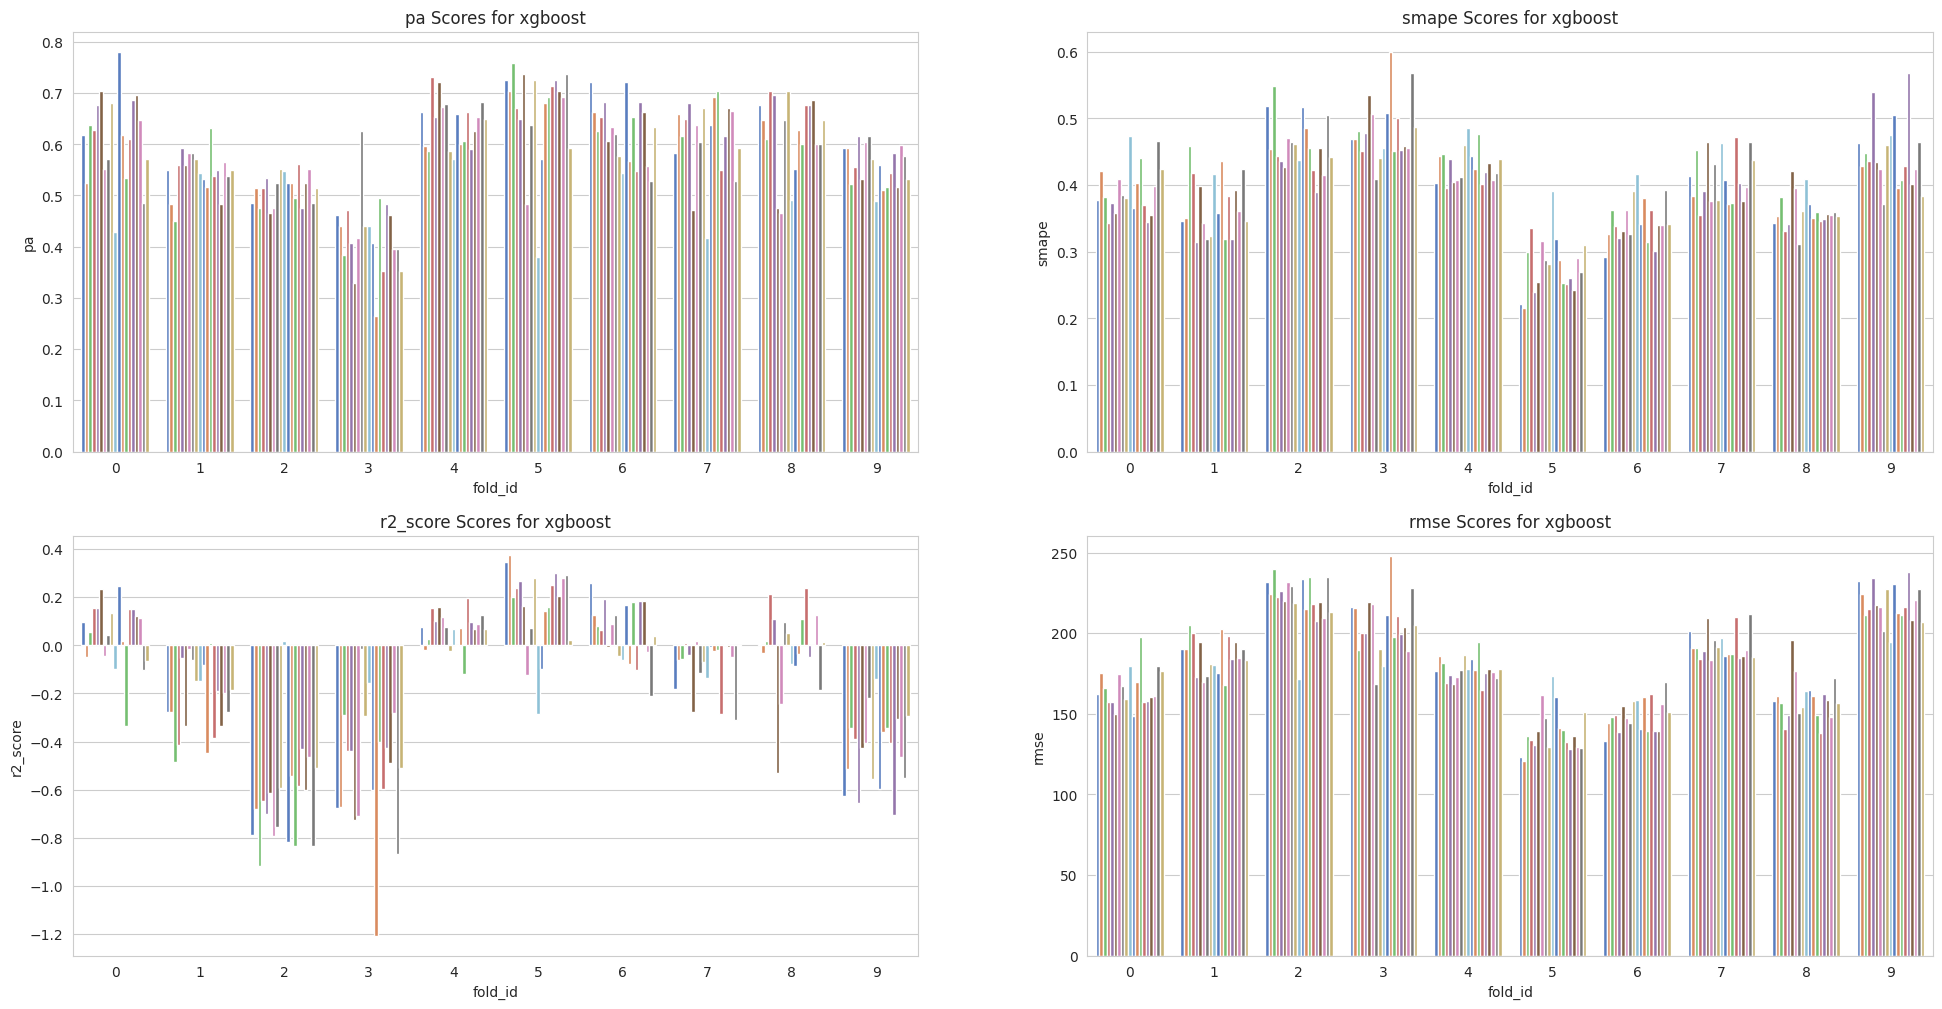

In [25]:
visualize_dataframe(current_files)